## Visuaize Bond Cleavage and BDE of the ground truth molecules formed.

[*] Loading dataset from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt...
[*] Hunting for 7 UNIQUE molecules with cleavage events...

[*] Visualizing Graph Index 0 | CE: 35.0 eV | Total Cuts: 2
[*] SMILES: Cc1cc2c(s1)Nc1ccccc1N=C2N1CCN(C)CC1


/tmp/ipykernel_1832848/3654187431.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dataset = torch.load(data_path)


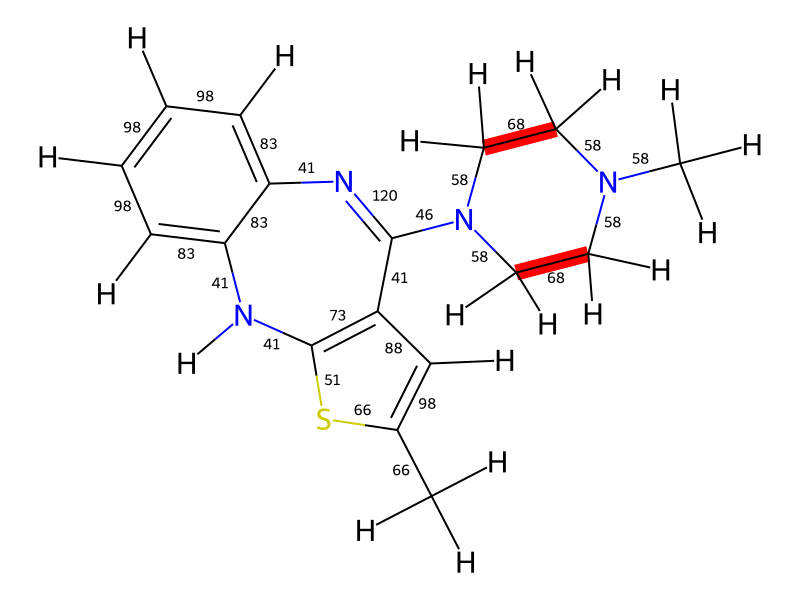


[*] Visualizing Graph Index 72 | CE: 35.0 eV | Total Cuts: 15
[*] SMILES: CCCCC(C)C(OC(=O)CC(CC(=O)O)C(=O)O)C(CC(C)CC(O)CCCCCCC(O)C(C)N)OC(=O)CC(CC(=O)O)C(=O)O


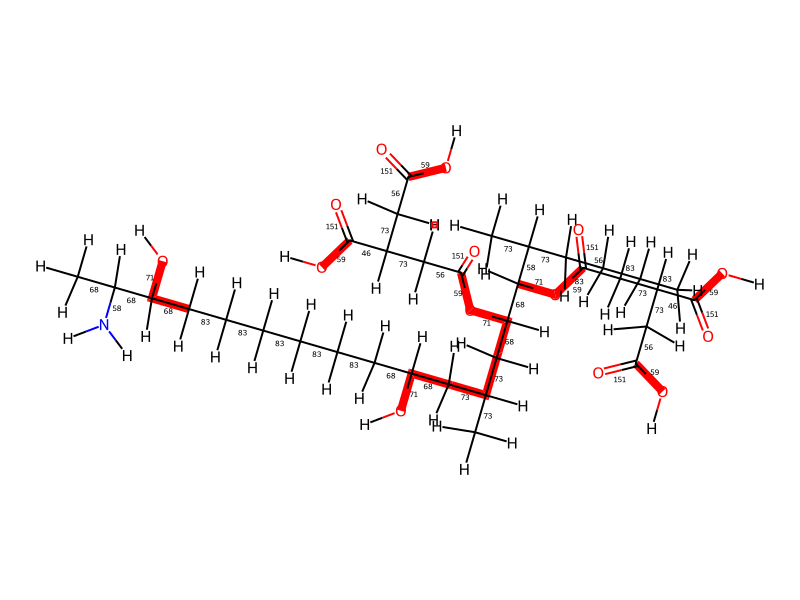


[*] Visualizing Graph Index 96 | CE: 35.0 eV | Total Cuts: 9
[*] SMILES: CC1OC(OC2C(O)C(OCCc3ccc(O)c(O)c3)OC(CO)C2OC(=O)C=Cc2ccc(O)c(O)c2)C(O)C(O)C1O


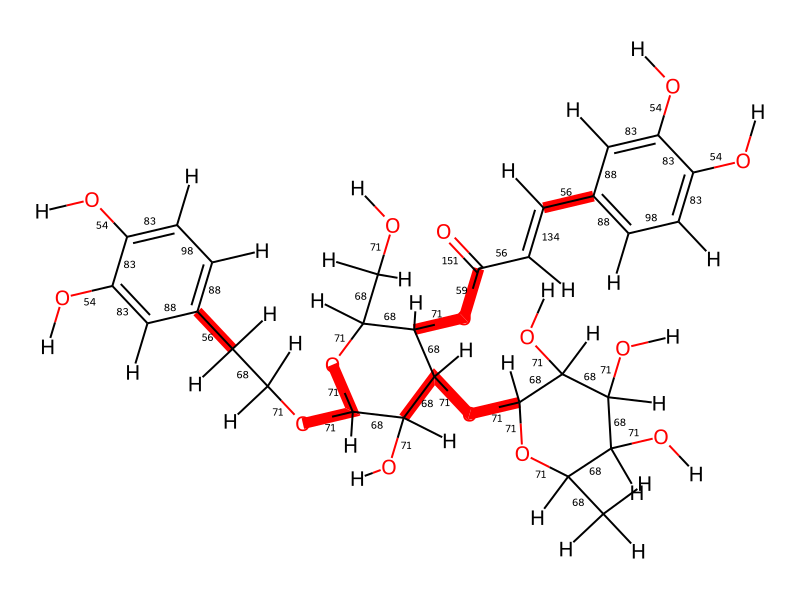


[*] Visualizing Graph Index 116 | CE: 35.0 eV | Total Cuts: 4
[*] SMILES: C(CC=Nc1ccccc1)=Nc1ccccc1


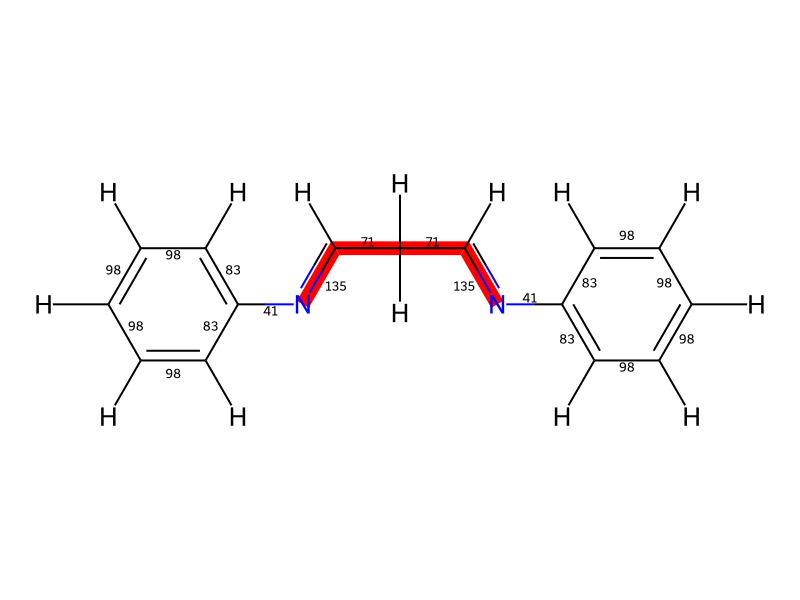


[*] Visualizing Graph Index 119 | CE: 35.0 eV | Total Cuts: 1
[*] SMILES: C#CC1(O)C(CO)OC(n2ccc(N)nc2=O)C1O


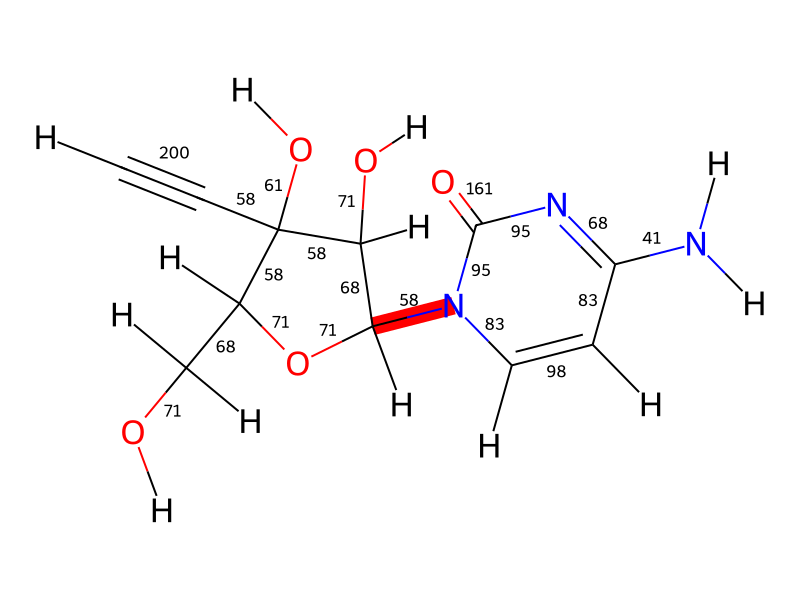


[*] Visualizing Graph Index 128 | CE: 35.0 eV | Total Cuts: 8
[*] SMILES: CCc1nn(C)c(C(=O)NCc2ccc(C(C)(C)C)cc2)c1Cl


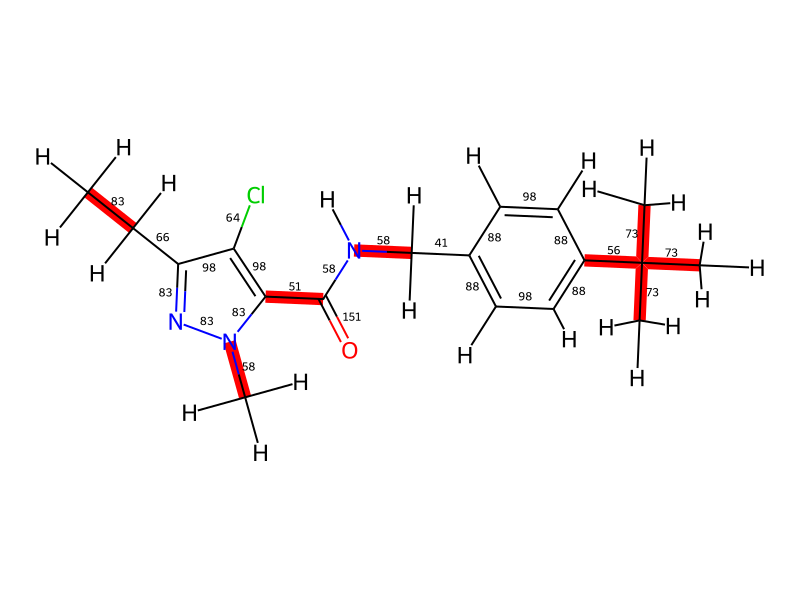


[*] Visualizing Graph Index 143 | CE: 35.0 eV | Total Cuts: 2
[*] SMILES: CNC(=O)Oc1cc(C)c([S+](C)[O-])c(C)c1


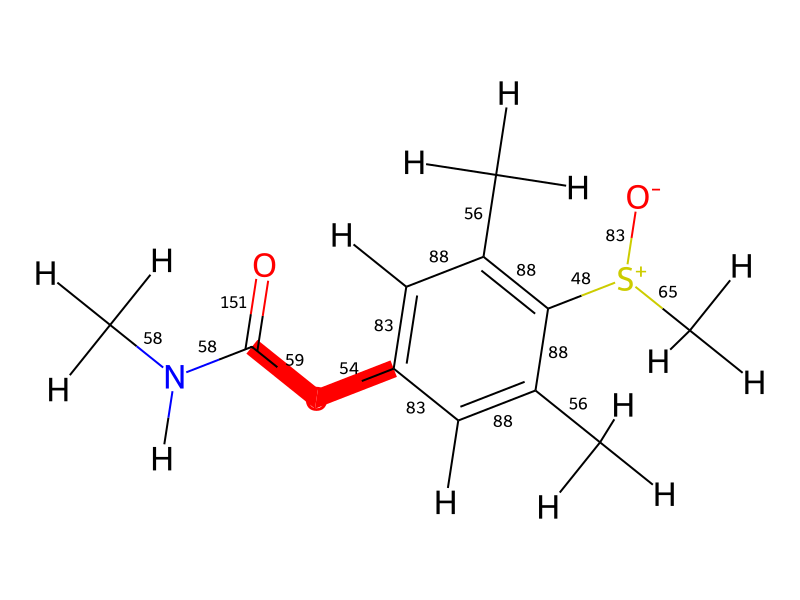

In [6]:
import torch
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import Image, display

# ==========================================
# 1. VISUALIZATION FUNCTION 
# ==========================================
def visualize_ground_truth_inline(pyg_data, graph_idx=0):
    """
    Renders a 2D molecule from a PyG Data object directly in a Jupyter Notebook.
    Forces a solid white background, labels BDEs, and highlights cuts in RED.
    """
    smiles = getattr(pyg_data, 'smiles', None)
    if not smiles: return

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol) 
    Chem.rdDepictor.Compute2DCoords(mol)

    edge_index = pyg_data.edge_index.numpy()
    edge_attr = pyg_data.edge_attr.numpy()
    y_cleavage = pyg_data.y_cleavage.numpy()

    highlight_bonds = []
    bond_colors = {}

    for bond in mol.GetBonds():
        u = bond.GetBeginAtomIdx()
        v = bond.GetEndAtomIdx()
        bond_idx = bond.GetIdx()

        match_idx = np.where((edge_index[0] == u) & (edge_index[1] == v))[0]
        
        if len(match_idx) > 0:
            tensor_idx = match_idx[0]
            bde_val = edge_attr[tensor_idx, 0] 
            is_cut = y_cleavage[tensor_idx]    
            
            bond.SetProp("bondNote", f"{bde_val:.0f}")
            
            if is_cut == 1.0:
                highlight_bonds.append(bond_idx)
                bond_colors[bond_idx] = (1.0, 0.0, 0.0) # Bright Red

    # Solid White Canvas
    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(800, 600)
    opts = drawer.drawOptions()
    opts.addStereoAnnotation = False
    opts.bondNoteFontSize = 14
    opts.clearBackground = True 
    opts.setBackgroundColour((1.0, 1.0, 1.0, 1.0)) 

    drawer.DrawMolecule(mol, highlightAtoms=[], highlightBonds=highlight_bonds, highlightBondColors=bond_colors)
    drawer.FinishDrawing()
    
    img_bytes = drawer.GetDrawingText()
    
    ce_val = edge_attr[0, 1] if len(edge_attr) > 0 else "N/A"
    print(f"\n[*] Visualizing Graph Index {graph_idx} | CE: {ce_val} eV | Total Cuts: {int(y_cleavage.sum() / 2)}")
    print(f"[*] SMILES: {smiles}")
    display(Image(data=img_bytes, format='png'))

# ==========================================
# 2. SMART HUNTING EXECUTION LOOP
# ==========================================
data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt"
print(f"[*] Loading dataset from {data_path}...")
dataset = torch.load(data_path)

seen_smiles = set()
graphs_shown = 0
target_graphs = 7

print(f"[*] Hunting for {target_graphs} UNIQUE molecules with cleavage events...")

for i, data in enumerate(dataset):
    smiles = getattr(data, 'smiles', '')
    
    # Logic: It must have a cut bond AND we must not have drawn it yet
    if data.y_cleavage.sum().item() > 0 and smiles not in seen_smiles:
        visualize_ground_truth_inline(data, graph_idx=i)
        seen_smiles.add(smiles)
        graphs_shown += 1
        
    if graphs_shown >= target_graphs:
        break

if graphs_shown == 0:
    print("[-] Could not find any graphs with cleavages.")

In [3]:
import torch
data = torch.load("/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt")

unique_smiles = set()
for graph in data:
    unique_smiles.add(graph.smiles)

print(f"Total Graphs: {len(data)}")
print(f"Unique Molecules: {len(unique_smiles)}")

/tmp/ipykernel_1127965/3492802897.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gy

Total Graphs: 260706
Unique Molecules: 30101


[*] Loading merged configurations and initializing DESAF-Net Architecture...
[*] Loading trained Phase 1 weights from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/desaf_phase1_best.pt...


/tmp/ipykernel_4007467/4027402932.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(WEIGHTS_PATH, map_location=device)


[*] Loading dataset from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt...
[*] Loading pre-computed Phase 1 graphs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt into RAM...
[+] Loaded 260706 graphs.

[*] Scanning for structurally unique molecules...

[+] Found 5 unique molecule indices: [0, 72, 96, 116, 119, 128, 143, 181, 209, 228]

[*] Visualizing Inference for Graph Index 0
[*] SMILES: Cc1cc2c(s1)Nc1ccccc1N=C2N1CCN(C)CC1
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


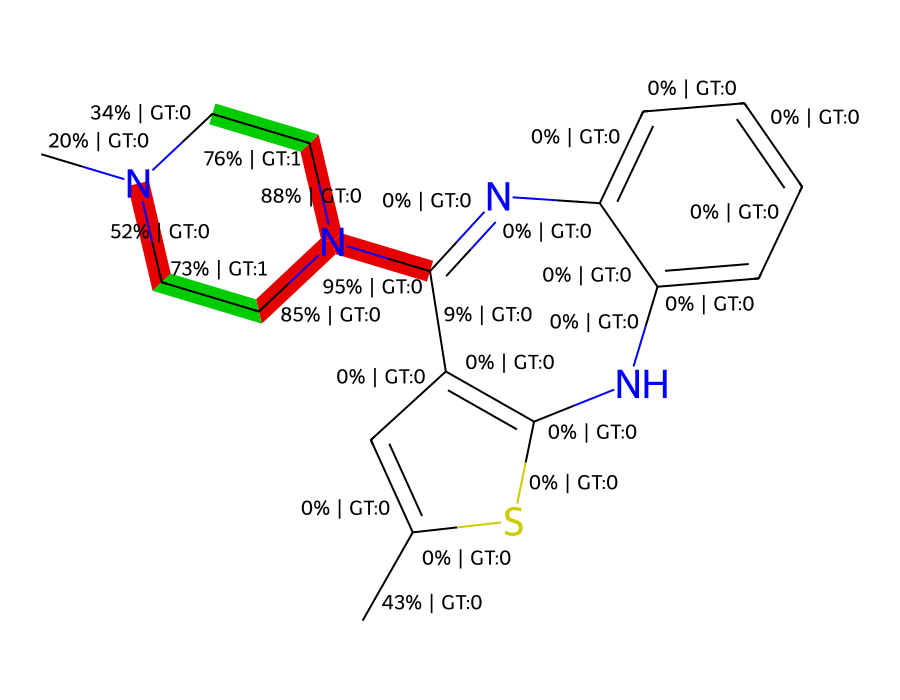


[*] Visualizing Inference for Graph Index 72
[*] SMILES: CCCCC(C)C(OC(=O)CC(CC(=O)O)C(=O)O)C(CC(C)CC(O)CCCCCCC(O)C(C)N)OC(=O)CC(CC(=O)O)C(=O)O
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


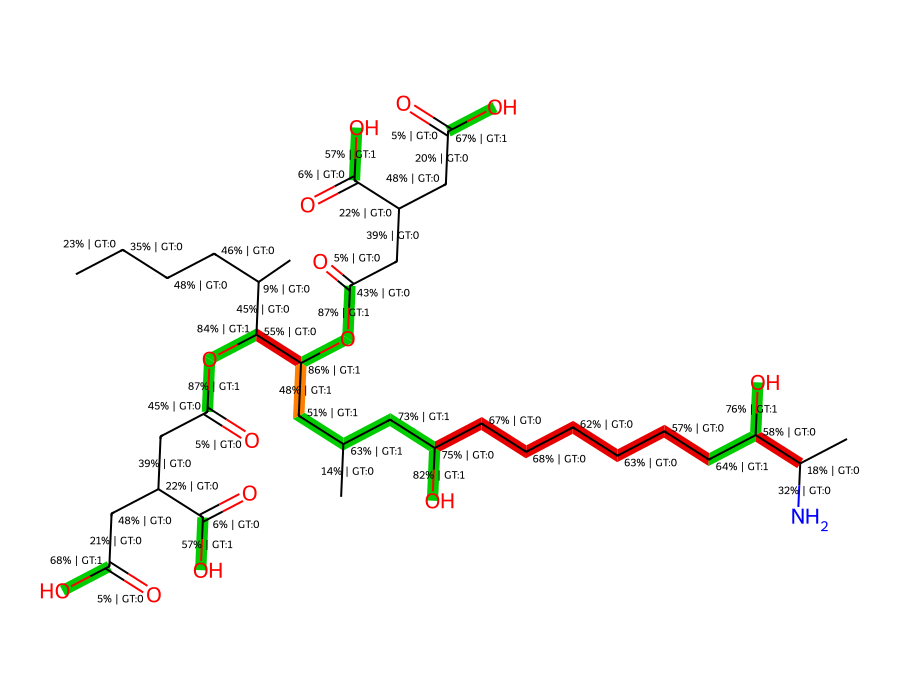


[*] Visualizing Inference for Graph Index 96
[*] SMILES: CC1OC(OC2C(O)C(OCCc3ccc(O)c(O)c3)OC(CO)C2OC(=O)C=Cc2ccc(O)c(O)c2)C(O)C(O)C1O
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


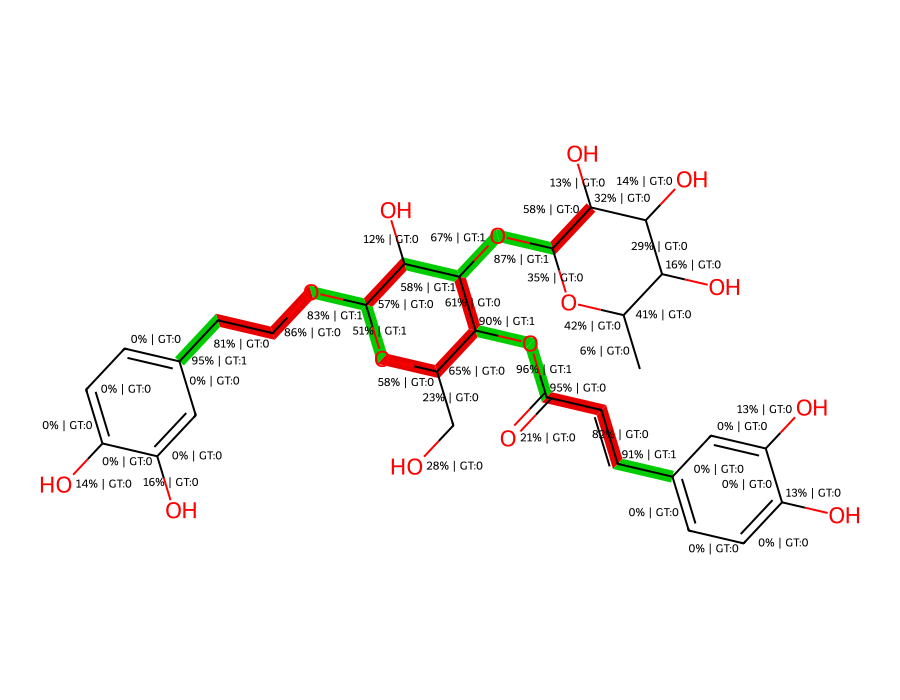


[*] Visualizing Inference for Graph Index 116
[*] SMILES: C(CC=Nc1ccccc1)=Nc1ccccc1
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


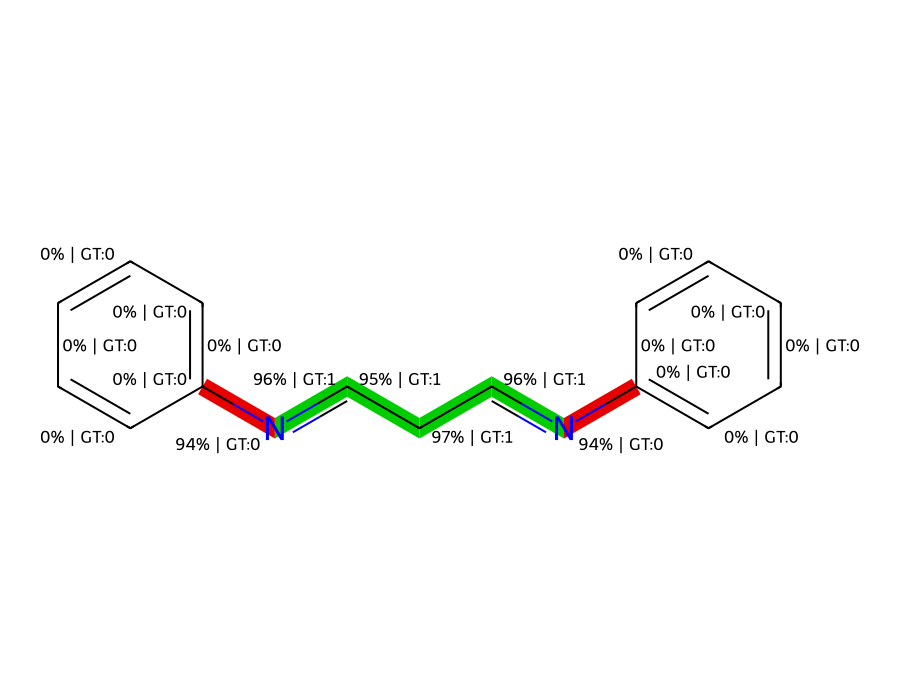


[*] Visualizing Inference for Graph Index 119
[*] SMILES: C#CC1(O)C(CO)OC(n2ccc(N)nc2=O)C1O
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


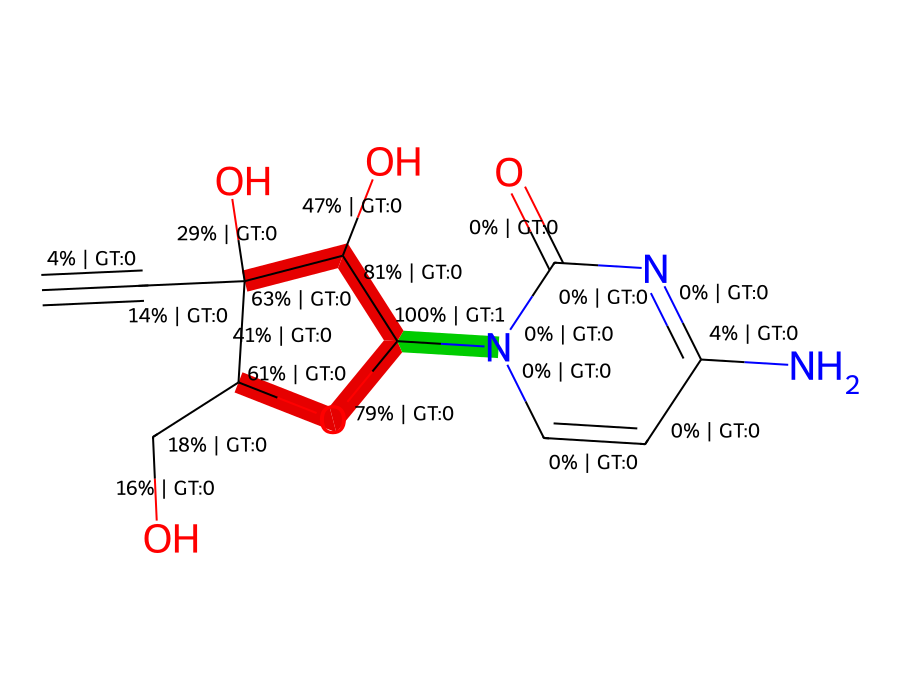


[*] Visualizing Inference for Graph Index 128
[*] SMILES: CCc1nn(C)c(C(=O)NCc2ccc(C(C)(C)C)cc2)c1Cl
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


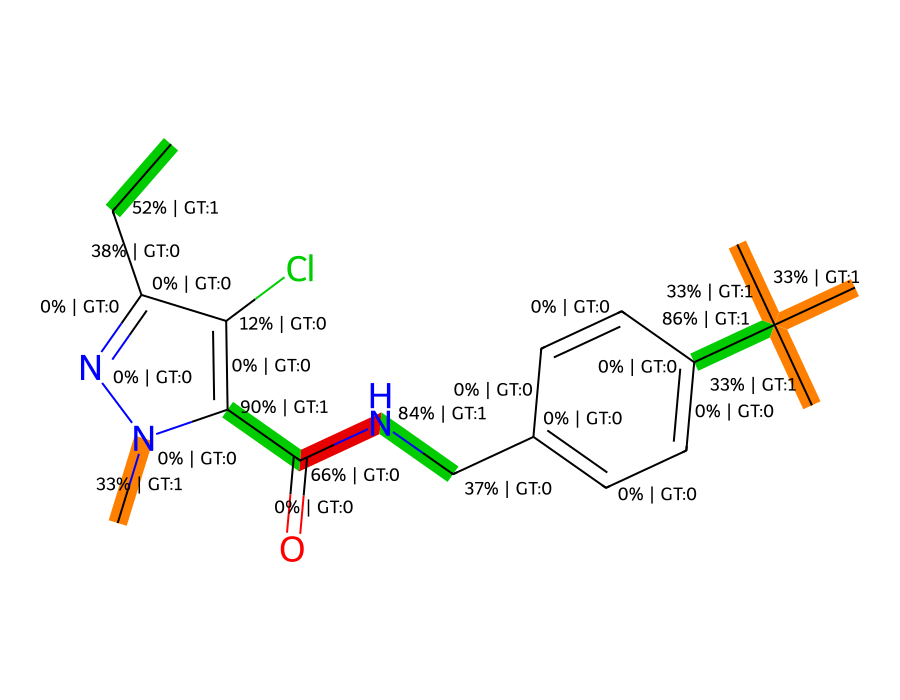


[*] Visualizing Inference for Graph Index 143
[*] SMILES: CNC(=O)Oc1cc(C)c([S+](C)[O-])c(C)c1
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


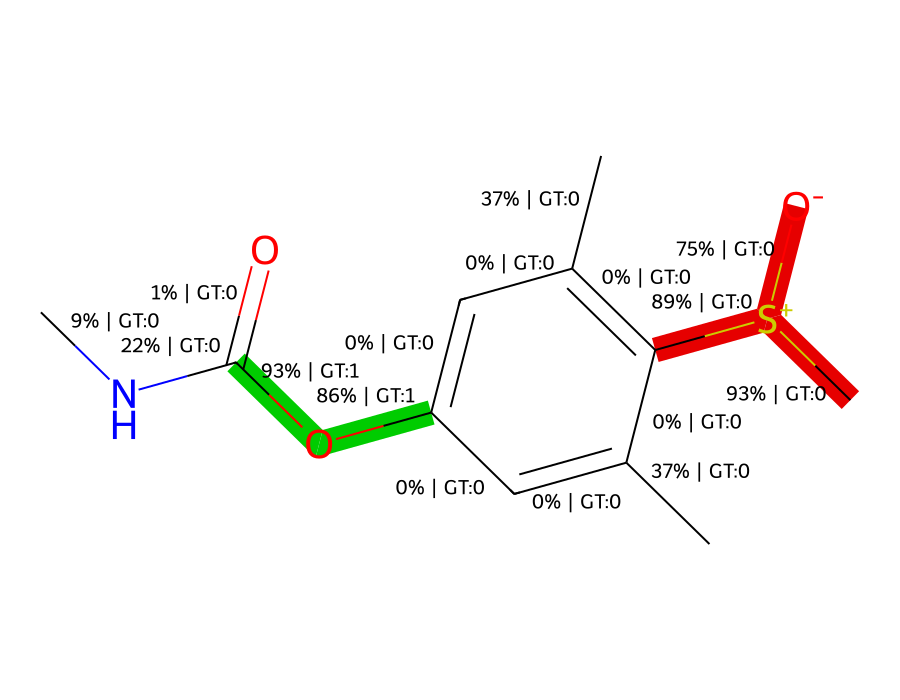


[*] Visualizing Inference for Graph Index 181
[*] SMILES: CC(=O)c1c(O)c(C)c(O)c2c1OC1=CC(=O)C(C(C)=NCC(=O)N3CCc4ccccc4C3)C(=O)C12C
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


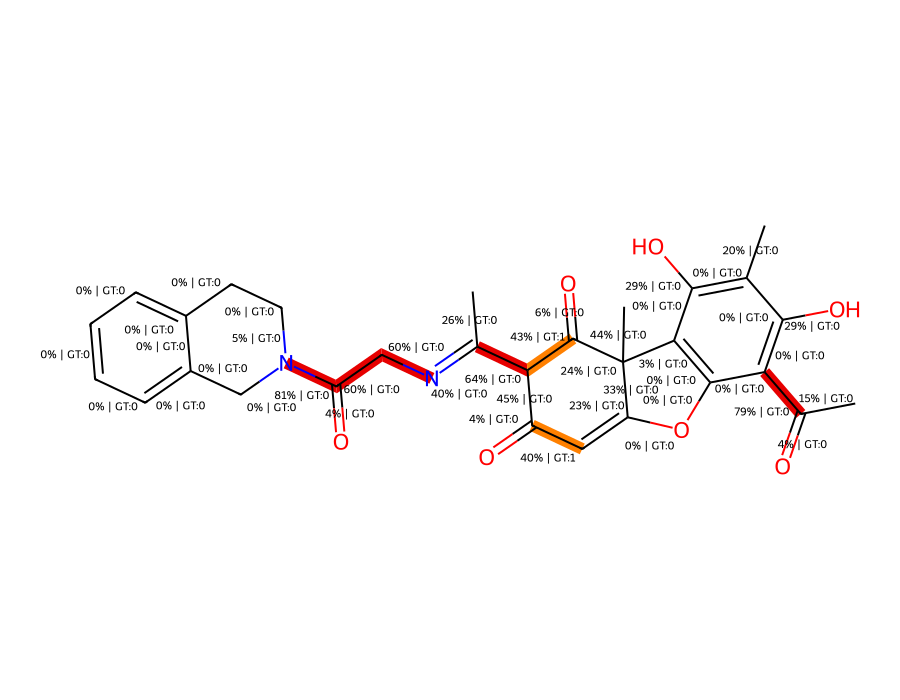


[*] Visualizing Inference for Graph Index 209
[*] SMILES: CCC(C)C1NC(=O)C(C(C)CC)NC1=O
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


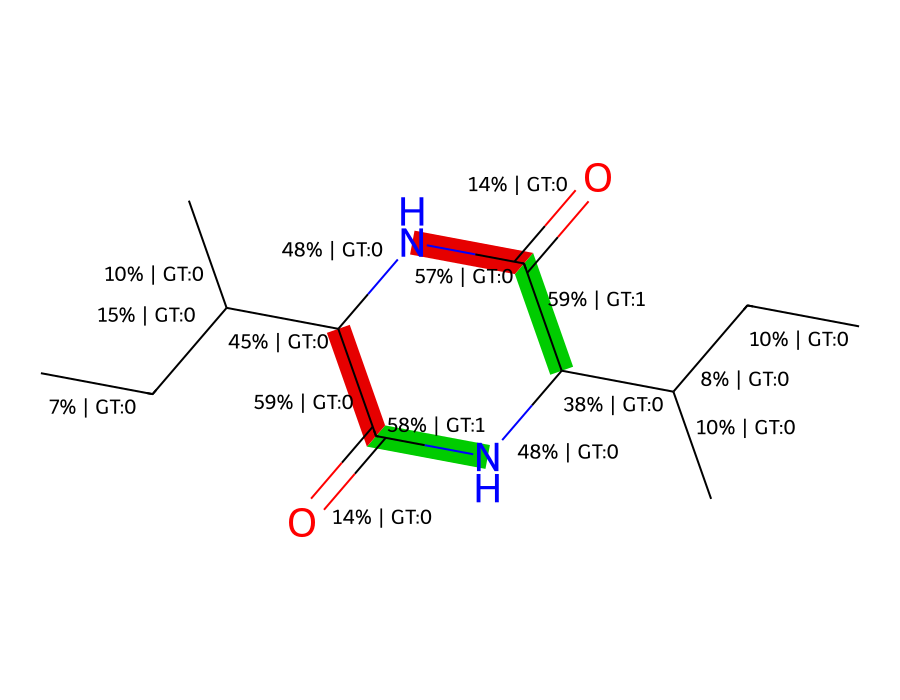


[*] Visualizing Inference for Graph Index 228
[*] SMILES: Cn1ncc2c(NCCO)nc(Nc3ccc(F)c(F)c3)nc21
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


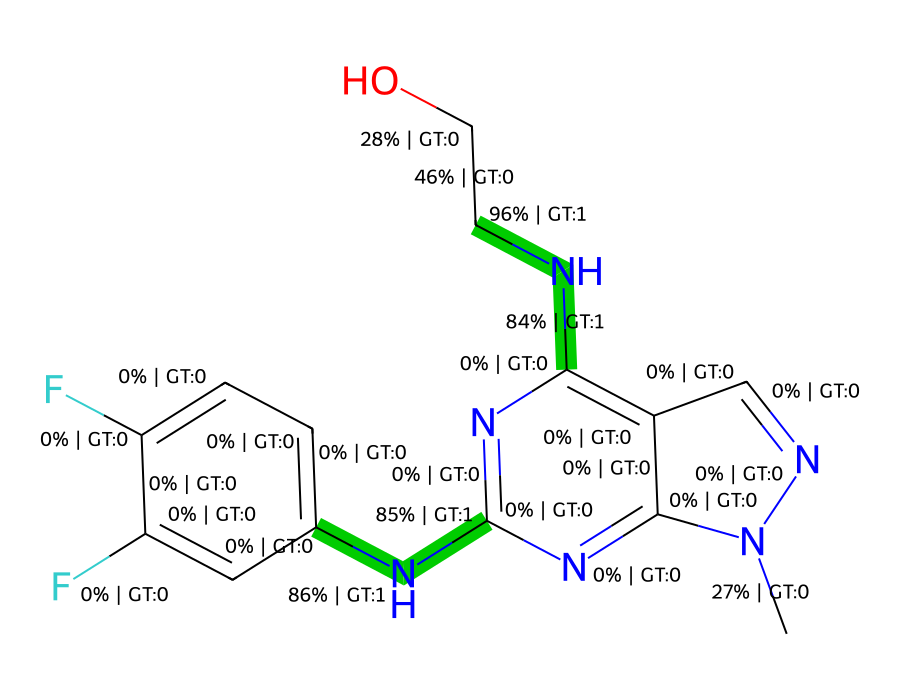

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.notebook import tqdm  # JUPYTER FIX: Beautiful HTML progress bars
import yaml
import os
import sys
import wandb
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import Image, display
import numpy as np

# --- SETUP PATHS ---
cwd = Path.cwd().parent
# Make sure your notebook is running in the directory ABOVE 'data_loaders' and 'model'
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'fiar')) 
sys.path.insert(0, os.path.join(cwd, 'model', 'fiar'))
sys.path.insert(0, os.path.join(cwd, 'model', 'transport_model', 'bifurcate'))
parent_directory = os.path.dirname(cwd.parent)
sys.path.insert(0, os.path.join(parent_directory, 'tmach007', 'massformer', 'src', 'massformer'))

try:
    from data_loader import Phase1EdgeDataset, phase1_collate_fn
    from phase1_model import DESAFNet
except ImportError as e:
    print(f"[-] Error importing custom modules: {e}")
    # JUPYTER FIX: Prevent kernel death by raising instead of sys.exit()
    raise e 

def load_and_merge_configs(template_path="template.yml", custom_path="demo.yml"):
    """Merges the base template with the custom demo configurations."""
    with open(template_path, 'r', encoding='utf-8') as f: config = yaml.safe_load(f)
    if os.path.exists(custom_path):
        with open(custom_path, 'r', encoding='utf-8') as f: custom_config = yaml.safe_load(f)
        for section, subdict in custom_config.items():
            if isinstance(subdict, dict):
                if section not in config: config[section] = {}
                for k, v in subdict.items(): config[section][k] = v
            else: config[section] = subdict
    return config

def visualize_model_predictions(model, dataset, graph_idx, threshold=0.5):
    """
    Runs inference on a single graph and visualizes the model's confidence 
    vs. the ground truth labels on the 2D molecule.
    """
    device = next(model.parameters()).device
    model.eval()
    
    # 1. Retrieve the raw PyG graph and reconstruct the RDKit molecule
    pyg_data = dataset.graphs[graph_idx]
    smiles = getattr(pyg_data, 'smiles', None)
    if not smiles: 
        print(f"[-] No SMILES found for graph {graph_idx}")
        return
        
    mol = Chem.MolFromSmiles(smiles)
    Chem.rdDepictor.Compute2DCoords(mol)
    
    # 2. Isolate the item and create a batch of size 1 using our custom collator
    mf_item = dataset[graph_idx]
    if mf_item is None:
        print("[-] Graphormer padding failed for this molecule. Skipping.")
        return
        
    batch = phase1_collate_fn([mf_item])
    batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
    
    # 3. Run Inference
    with torch.no_grad():
        logits = model.forward_phase1(batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        
    y_true = batch['y_cleavage'].cpu().numpy()
    edge_index = batch['edge_index'].cpu().numpy()
    
    # 4. Map Predictions to RDKit Bonds
    highlight_bonds = []
    bond_colors = {}
    
    for bond in mol.GetBonds():
        u = bond.GetBeginAtomIdx()
        v = bond.GetEndAtomIdx()
        bond_idx = bond.GetIdx()

        # Find where this specific undirected RDKit bond matches our directed edge_index
        match_idx = np.where((edge_index[0] == u) & (edge_index[1] == v))[0]
        
        if len(match_idx) > 0:
            tensor_idx = match_idx[0]
            pred_prob = probs[tensor_idx]
            gt_label = int(y_true[tensor_idx])
            
            # Annotate the bond with Prediction % and Ground Truth
            bond.SetProp("bondNote", f"{pred_prob*100:.0f}% | GT:{gt_label}")
            
            # Color Coding Logic based on the threshold
            if pred_prob >= threshold:
                highlight_bonds.append(bond_idx)
                if gt_label == 1:
                    # True Positive: Model confidently predicted a real cut (Green)
                    bond_colors[bond_idx] = (0.0, 0.8, 0.0) 
                else:
                    # False Positive: Model confidently hallucinated a cut (Red)
                    bond_colors[bond_idx] = (0.9, 0.0, 0.0)
            else:
                if gt_label == 1:
                    # False Negative: Model missed a real cut (Orange)
                    highlight_bonds.append(bond_idx)
                    bond_colors[bond_idx] = (1.0, 0.5, 0.0)

    # 5. Draw the Molecule
    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(900, 700)
    opts = drawer.drawOptions()
    opts.addStereoAnnotation = False
    opts.bondNoteFontSize = 14
    opts.clearBackground = True 
    opts.setBackgroundColour((1.0, 1.0, 1.0, 1.0)) 

    drawer.DrawMolecule(mol, highlightAtoms=[], highlightBonds=highlight_bonds, highlightBondColors=bond_colors)
    drawer.FinishDrawing()
    
    print(f"\n[*] Visualizing Inference for Graph Index {graph_idx}")
    print(f"[*] SMILES: {smiles}")
    print("[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut")
    
    # Jupyter specific display command
    display(Image(data=drawer.GetDrawingText(), format='png'))

# ==========================================
# JUPYTER EXECUTION CONFIGURATION
# ==========================================
# Adjust these paths to match your actual setup
DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt"
WEIGHTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/desaf_phase1_best.pt"
TEMPLATE_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"
CUSTOM_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Merged Configs and Initialize Model
print("[*] Loading merged configurations and initializing DESAF-Net Architecture...")
full_config = load_and_merge_configs(TEMPLATE_CONFIG_PATH, CUSTOM_CONFIG_PATH)
model = DESAFNet(model_config=full_config['model']).to(device)

# 2. Load Weights
print(f"[*] Loading trained Phase 1 weights from {WEIGHTS_PATH}...")
checkpoint = torch.load(WEIGHTS_PATH, map_location=device)
model.load_state_dict(checkpoint, strict=False)

# 3. Load Dataset (into RAM)
print(f"[*] Loading dataset from {DATA_PATH}...")
dataset = Phase1EdgeDataset(DATA_PATH)

# ==========================================
# SMART MOLECULE EXPLORER
# ==========================================
print("\n[*] Scanning for structurally unique molecules...")
unique_smiles = set()
fascinating_indices = []

# Scan until we find 5 completely different molecules that actually break
for i, data in enumerate(dataset.graphs):
    if data.y_cleavage.sum().item() > 1: # Must have at least 2 cuts
        smiles = getattr(data, 'smiles', None)
        if smiles and smiles not in unique_smiles:
            unique_smiles.add(smiles)
            fascinating_indices.append(i)
            
    if len(fascinating_indices) >= 10:
        break

print(f"\n[+] Found 5 unique molecule indices: {fascinating_indices}")

# CHANGE THIS to any of the numbers printed above!
target_idx = fascinating_indices[1] 

for i in fascinating_indices:
    # Render
    visualize_model_predictions(model, dataset, graph_idx=i, threshold=0.5)

[*] Loading merged configurations and initializing DESAF-Net Architecture...
[*] Loading trained Phase 1 weights from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/desaf_phase1_best.pt...


/tmp/ipykernel_2899634/1575256.py:217: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(WEIGHTS_PATH, map_location=device)


[*] Loading dataset from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt...
[*] Loading pre-computed Phase 1 graphs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt into RAM...


/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_loaders/fiar/data_loader.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.graphs = torch.load(processed

[+] Loaded 260706 graphs.

[*] Running Dataset-wide Evaluation for Hard Metrics (Sample Size: 2000)...


Calculating Metrics:   1%|          | 2000/260706 [00:30<1:06:46, 64.57it/s]



🚀 PHASE 1 EDGE REGRESSOR - HARD METRICS 🚀
Global Precision (Thresh 0.5): 0.2157  <- (Resists Alphabet Soup Exploit)
Global Recall    (Thresh 0.5): 0.7994  <- (Resists Missing Peaks)
Global F1-Score  (Thresh 0.5): 0.3397
Global AUPRC                   : 0.4305  <- (The Imbalanced Data Gold Standard)
------------------------------------------------------------
Top-3 Hit Rate: 31.1% (Found 2222 out of 7144 true cuts)
Top-5 Hit Rate: 44.9% (Found 3207 out of 7144 true cuts)


[*] Scanning for structurally unique molecules...

[+] Found 5 unique molecule indices: [0, 72, 96, 116, 119]

[*] Visualizing Inference for Graph Index 0
[*] SMILES: Cc1cc2c(s1)Nc1ccccc1N=C2N1CCN(C)CC1
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


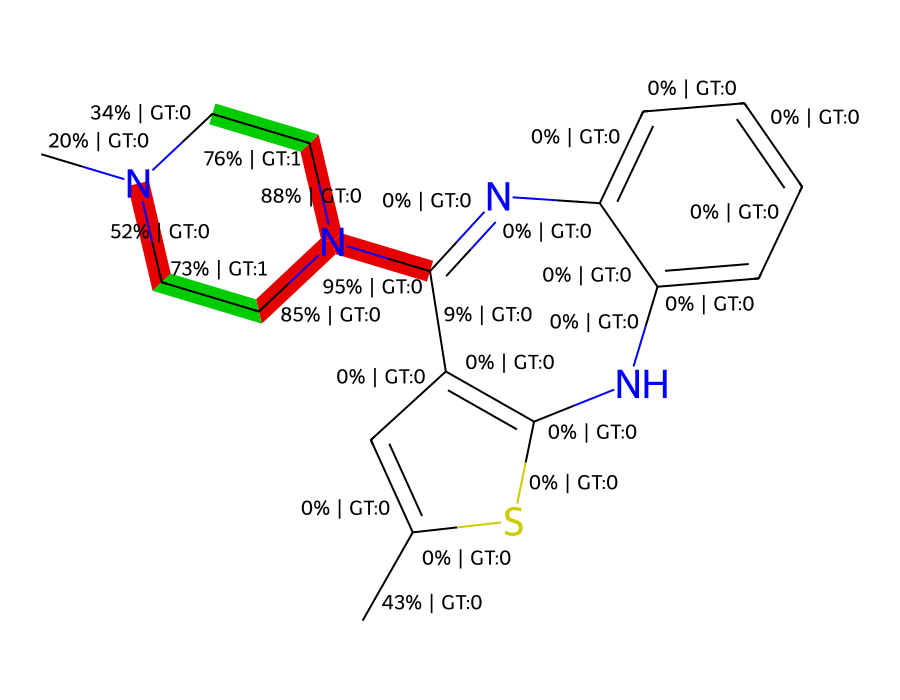


[*] Visualizing Inference for Graph Index 72
[*] SMILES: CCCCC(C)C(OC(=O)CC(CC(=O)O)C(=O)O)C(CC(C)CC(O)CCCCCCC(O)C(C)N)OC(=O)CC(CC(=O)O)C(=O)O
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


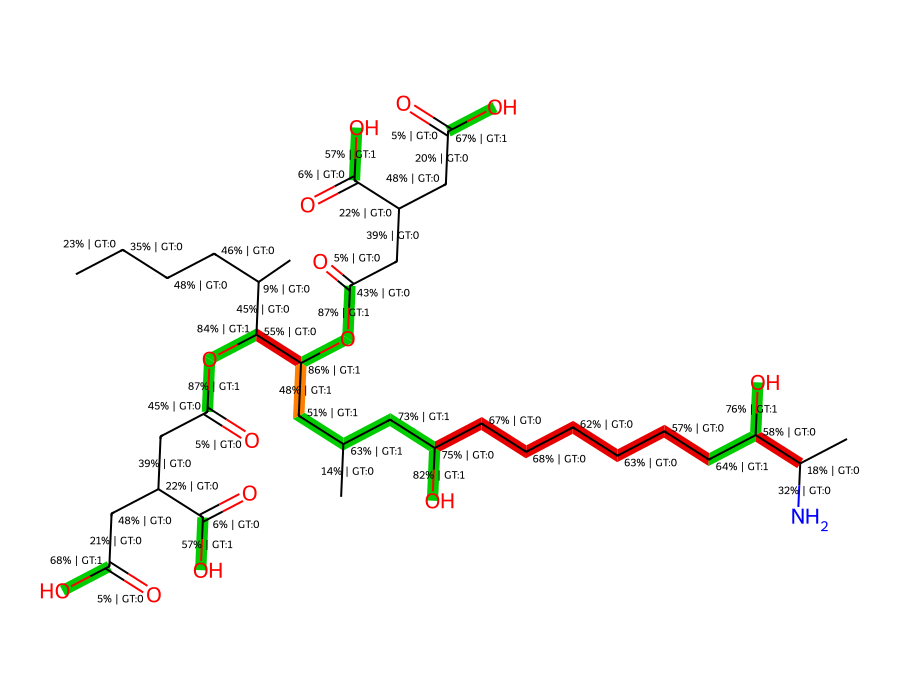


[*] Visualizing Inference for Graph Index 96
[*] SMILES: CC1OC(OC2C(O)C(OCCc3ccc(O)c(O)c3)OC(CO)C2OC(=O)C=Cc2ccc(O)c(O)c2)C(O)C(O)C1O
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


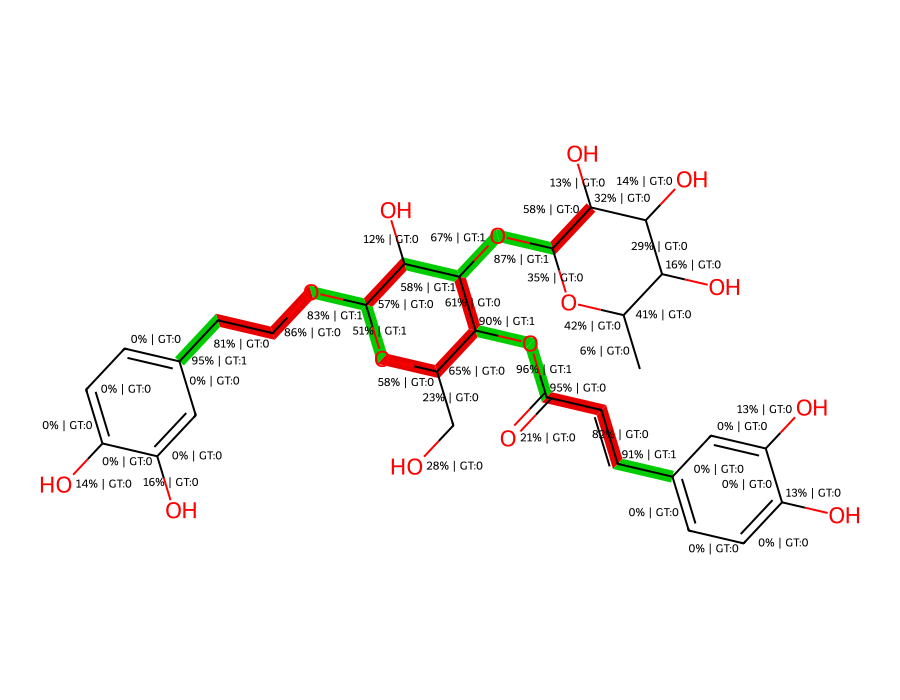


[*] Visualizing Inference for Graph Index 116
[*] SMILES: C(CC=Nc1ccccc1)=Nc1ccccc1
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


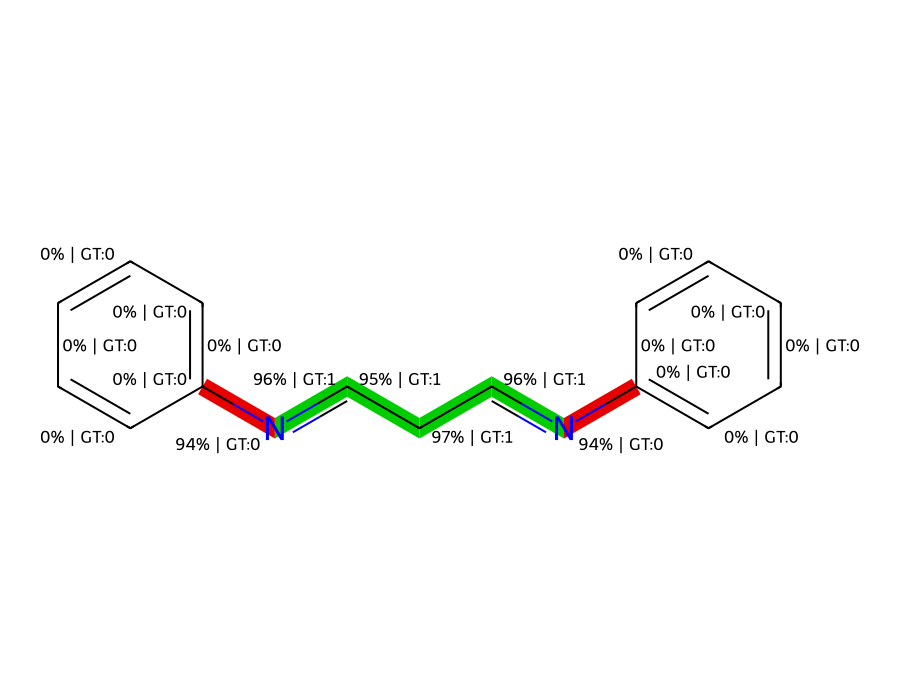


[*] Visualizing Inference for Graph Index 119
[*] SMILES: C#CC1(O)C(CO)OC(n2ccc(N)nc2=O)C1O
[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut


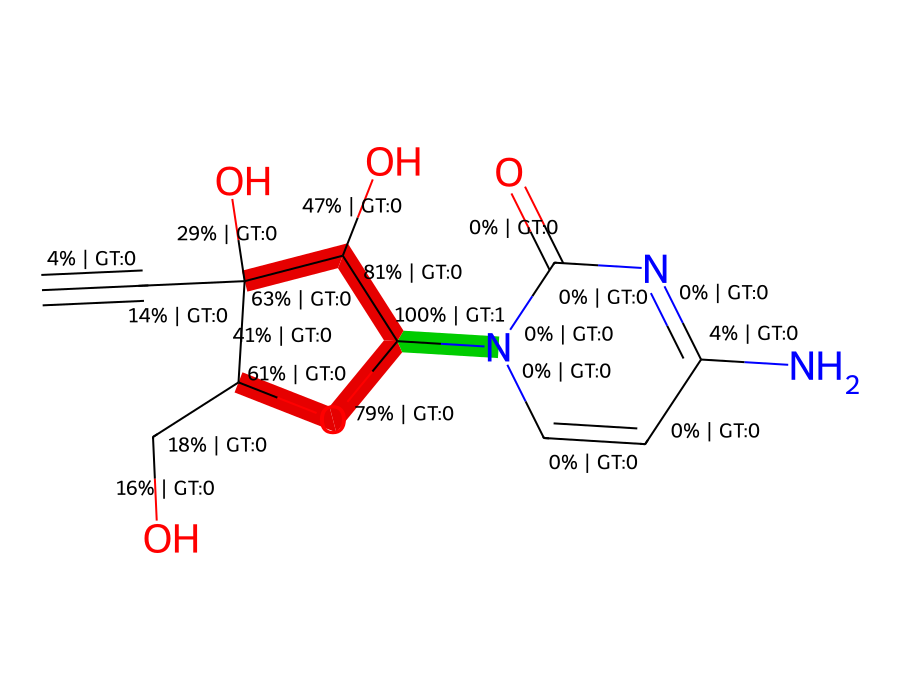

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import yaml
import os
import sys
import wandb
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import Image, display
import numpy as np

# --- NEW METRICS IMPORTS ---
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# --- SETUP PATHS ---
cwd = Path.cwd().parent
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'fiar')) 
sys.path.insert(0, os.path.join(cwd, 'model', 'fiar'))
sys.path.insert(0, os.path.join(cwd, 'model', 'transport_model', 'bifurcate'))
parent_directory = os.path.dirname(cwd.parent)
sys.path.insert(0, os.path.join(parent_directory, 'tmach007', 'massformer', 'src', 'massformer'))

try:
    from data_loader import Phase1EdgeDataset, phase1_collate_fn
    from phase1_model import DESAFNet
except ImportError as e:
    print(f"[-] Error importing custom modules: {e}")
    raise e 

def load_and_merge_configs(template_path="template.yml", custom_path="demo.yml"):
    """Merges the base template with the custom demo configurations."""
    with open(template_path, 'r', encoding='utf-8') as f: config = yaml.safe_load(f)
    if os.path.exists(custom_path):
        with open(custom_path, 'r', encoding='utf-8') as f: custom_config = yaml.safe_load(f)
        for section, subdict in custom_config.items():
            if isinstance(subdict, dict):
                if section not in config: config[section] = {}
                for k, v in subdict.items(): config[section][k] = v
            else: config[section] = subdict
    return config

# ==========================================
# [NEW] HARD METRICS EVALUATOR
# ==========================================
def evaluate_hard_metrics(model, dataset, threshold=0.5, max_eval_samples=2000):
    """
    Calculates AUPRC, Precision, Recall, F1, and Top-K Accuracy.
    Uses batch_size=1 to safely isolate per-molecule Top-K edge rankings.
    """
    device = next(model.parameters()).device
    model.eval()

    all_y_true = []
    all_y_prob = []

    top3_hits, top5_hits, total_true_cuts_for_topk = 0, 0, 0
    total_graphs_with_cuts = 0

    print(f"\n[*] Running Dataset-wide Evaluation for Hard Metrics (Sample Size: {max_eval_samples})...")
    
    # We use batch_size=1 to perfectly isolate edges per molecule for the Top-K logic
    loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=phase1_collate_fn)

    with torch.no_grad():
        for i, batch in enumerate(tqdm(loader, desc="Calculating Metrics")):
            if i >= max_eval_samples:
                break
                
            if batch is None: continue
            batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
            
            logits = model.forward_phase1(batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            y_true = batch['y_cleavage'].cpu().numpy()

            all_y_true.extend(y_true)
            all_y_prob.extend(probs)

            # --- Top-K Calculation ---
            num_true_cuts = int(np.sum(y_true))
            if num_true_cuts > 0:
                total_graphs_with_cuts += 1
                total_true_cuts_for_topk += num_true_cuts

                # Get indices of the highest predicted probabilities
                sorted_indices = np.argsort(probs)[::-1] 
                
                top3_indices = sorted_indices[:3]
                top5_indices = sorted_indices[:5]

                # Count how many of the ground truth cuts were in those top spots
                top3_hits += np.sum(y_true[top3_indices])
                top5_hits += np.sum(y_true[top5_indices])

    all_y_true = np.array(all_y_true)
    all_y_prob = np.array(all_y_prob)
    preds = (all_y_prob >= threshold).astype(int)

    # Scikit-Learn Metrics
    precision = precision_score(all_y_true, preds, zero_division=0)
    recall = recall_score(all_y_true, preds, zero_division=0)
    f1 = f1_score(all_y_true, preds, zero_division=0)
    auprc = average_precision_score(all_y_true, all_y_prob)

    top3_acc = top3_hits / total_true_cuts_for_topk if total_true_cuts_for_topk > 0 else 0
    top5_acc = top5_hits / total_true_cuts_for_topk if total_true_cuts_for_topk > 0 else 0

    print("\n" + "="*60)
    print("🚀 PHASE 1 EDGE REGRESSOR - HARD METRICS 🚀")
    print("="*60)
    print(f"Global Precision (Thresh {threshold}): {precision:.4f}  <- (Resists Alphabet Soup Exploit)")
    print(f"Global Recall    (Thresh {threshold}): {recall:.4f}  <- (Resists Missing Peaks)")
    print(f"Global F1-Score  (Thresh {threshold}): {f1:.4f}")
    print(f"Global AUPRC                   : {auprc:.4f}  <- (The Imbalanced Data Gold Standard)")
    print("-" * 60)
    print(f"Top-3 Hit Rate: {top3_acc*100:.1f}% (Found {int(top3_hits)} out of {total_true_cuts_for_topk} true cuts)")
    print(f"Top-5 Hit Rate: {top5_acc*100:.1f}% (Found {int(top5_hits)} out of {total_true_cuts_for_topk} true cuts)")
    print("="*60 + "\n")

# ==========================================
# VISUALIZER
# ==========================================
def visualize_model_predictions(model, dataset, graph_idx, threshold=0.5):
    """
    Runs inference on a single graph and visualizes the model's confidence 
    vs. the ground truth labels on the 2D molecule.
    """
    device = next(model.parameters()).device
    model.eval()
    
    pyg_data = dataset.graphs[graph_idx]
    smiles = getattr(pyg_data, 'smiles', None)
    if not smiles: 
        return
        
    mol = Chem.MolFromSmiles(smiles)
    Chem.rdDepictor.Compute2DCoords(mol)
    
    mf_item = dataset[graph_idx]
    if mf_item is None: return
        
    batch = phase1_collate_fn([mf_item])
    batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
    
    with torch.no_grad():
        logits = model.forward_phase1(batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        
    y_true = batch['y_cleavage'].cpu().numpy()
    edge_index = batch['edge_index'].cpu().numpy()
    
    highlight_bonds = []
    bond_colors = {}
    
    for bond in mol.GetBonds():
        u = bond.GetBeginAtomIdx()
        v = bond.GetEndAtomIdx()
        bond_idx = bond.GetIdx()

        match_idx = np.where((edge_index[0] == u) & (edge_index[1] == v))[0]
        
        if len(match_idx) > 0:
            tensor_idx = match_idx[0]
            pred_prob = probs[tensor_idx]
            gt_label = int(y_true[tensor_idx])
            
            bond.SetProp("bondNote", f"{pred_prob*100:.0f}% | GT:{gt_label}")
            
            if pred_prob >= threshold:
                highlight_bonds.append(bond_idx)
                if gt_label == 1:
                    bond_colors[bond_idx] = (0.0, 0.8, 0.0) # True Positive (Green)
                else:
                    bond_colors[bond_idx] = (0.9, 0.0, 0.0) # False Positive (Red)
            else:
                if gt_label == 1:
                    highlight_bonds.append(bond_idx)
                    bond_colors[bond_idx] = (1.0, 0.5, 0.0) # False Negative (Orange)

    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(900, 700)
    opts = drawer.drawOptions()
    opts.addStereoAnnotation = False
    opts.bondNoteFontSize = 14
    opts.clearBackground = True 
    opts.setBackgroundColour((1.0, 1.0, 1.0, 1.0)) 

    drawer.DrawMolecule(mol, highlightAtoms=[], highlightBonds=highlight_bonds, highlightBondColors=bond_colors)
    drawer.FinishDrawing()
    
    print(f"\n[*] Visualizing Inference for Graph Index {graph_idx}")
    print(f"[*] SMILES: {smiles}")
    print("[*] Color Key: GREEN = True Cut | RED = Hallucinated Cut | ORANGE = Missed Cut")
    display(Image(data=drawer.GetDrawingText(), format='png'))


if __name__ == '__main__':
    # ==========================================
    # EXECUTION CONFIGURATION
    # ==========================================
    DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase1_graphs.pt"
    WEIGHTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/desaf_phase1_best.pt"
    TEMPLATE_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"
    CUSTOM_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("[*] Loading merged configurations and initializing DESAF-Net Architecture...")
    full_config = load_and_merge_configs(TEMPLATE_CONFIG_PATH, CUSTOM_CONFIG_PATH)
    model = DESAFNet(model_config=full_config['model']).to(device)

    print(f"[*] Loading trained Phase 1 weights from {WEIGHTS_PATH}...")
    checkpoint = torch.load(WEIGHTS_PATH, map_location=device)
    model.load_state_dict(checkpoint, strict=False)

    print(f"[*] Loading dataset from {DATA_PATH}...")
    dataset = Phase1EdgeDataset(DATA_PATH)

    # ------------------------------------------
    # 1. RUN HARD METRICS (For the ML Engineers)
    # ------------------------------------------
    evaluate_hard_metrics(model, dataset, threshold=0.5, max_eval_samples=2000)

    # ------------------------------------------
    # 2. RUN VISUALIZER (For the Bioinformaticians)
    # ------------------------------------------
    print("\n[*] Scanning for structurally unique molecules...")
    unique_smiles = set()
    fascinating_indices = []

    for i, data in enumerate(dataset.graphs):
        if data.y_cleavage.sum().item() > 1: 
            smiles = getattr(data, 'smiles', None)
            if smiles and smiles not in unique_smiles:
                unique_smiles.add(smiles)
                fascinating_indices.append(i)
                
        if len(fascinating_indices) >= 5:
            break

    print(f"\n[+] Found 5 unique molecule indices: {fascinating_indices}")

    for i in fascinating_indices:
        visualize_model_predictions(model, dataset, graph_idx=i, threshold=0.5)

[*] Loading merged configurations and initializing DESAF-Net Phase 2 Architecture...
[*] Loading trained Phase 2 weights from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/phase2_run3/desaf_phase2_best.pt...
[*] Loading dataset from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase2_graphs.pt...
[*] Loading Phase 2 graphs (with spectra) from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase2_graphs.pt...


/tmp/ipykernel_2899634/2898344239.py:256: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
/data/nas-gpu/wa

[+] Loaded 260706 pairs.

[*] Running Global RL Policy Evaluation (Sample Size: 2000)...


Calculating Phase 2 Metrics:   1%|          | 2000/260706 [00:42<1:30:59, 47.39it/s]



🚀 PHASE 2 RL ENGINE - GLOBAL METRICS 🚀
Avg Spectral Cosine Reward : 0.0709  <- (Single-Step Limit reached)
Avg Fragments / Molecule   : 3.20  <- (Parsimony Penalty verified)
Primary Peak Hit Rate      : 2.0%  <- (Percentage of experimental peaks found)


[*] Scanning for structurally unique molecules to visualize...

[+] Rendering 5 unique examples for visual presentation...


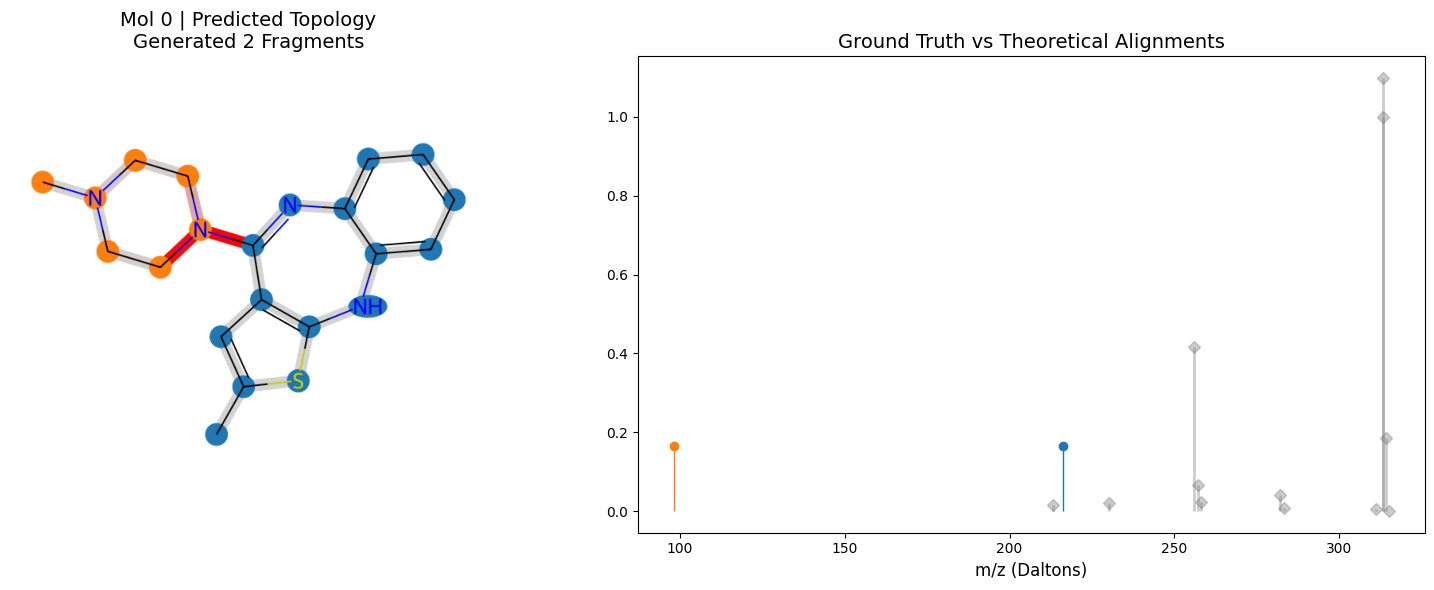

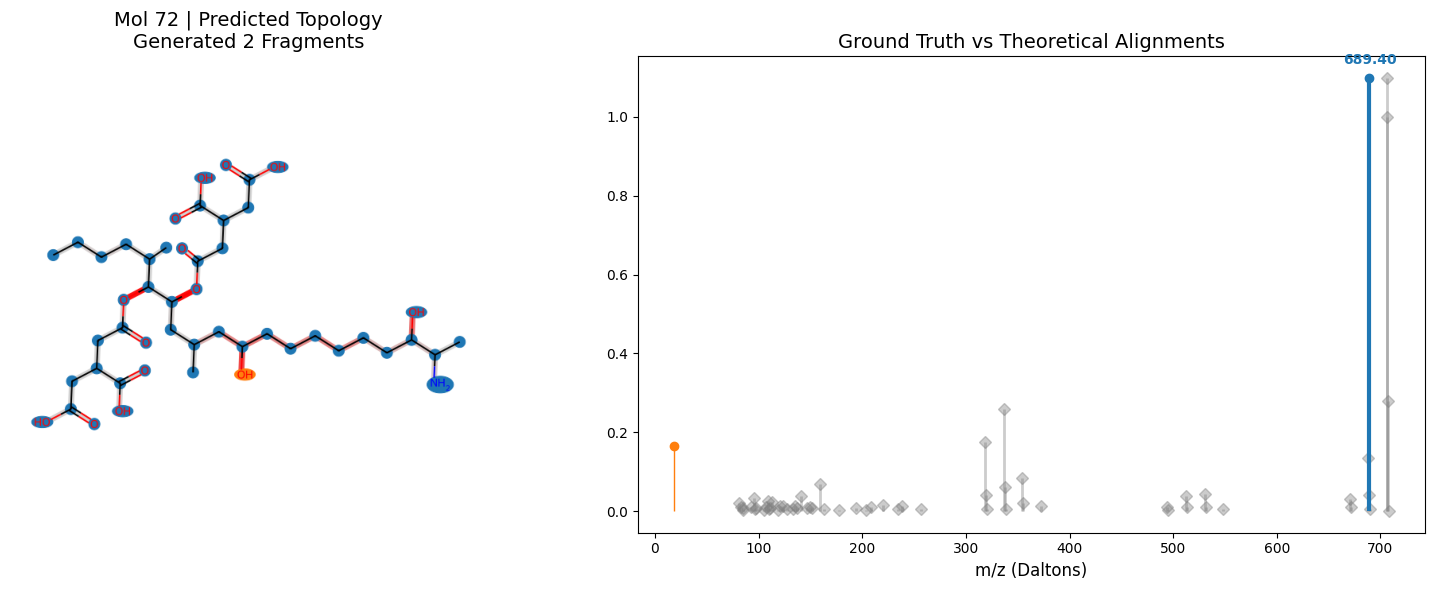

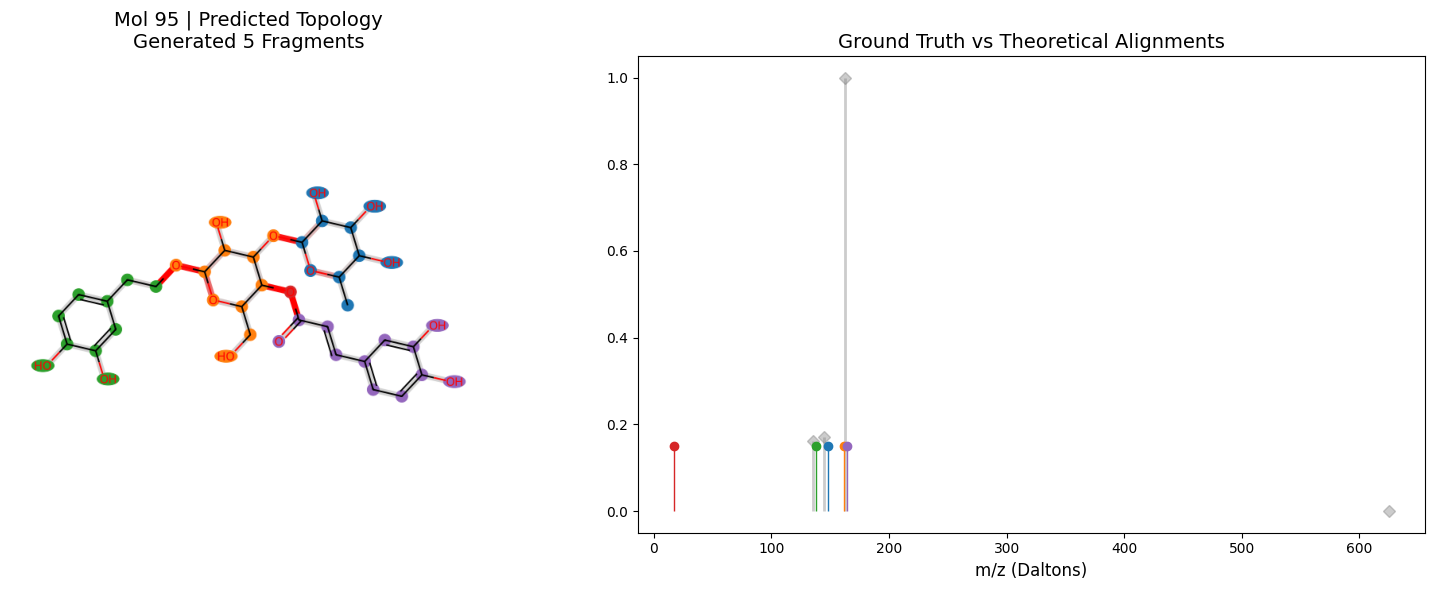

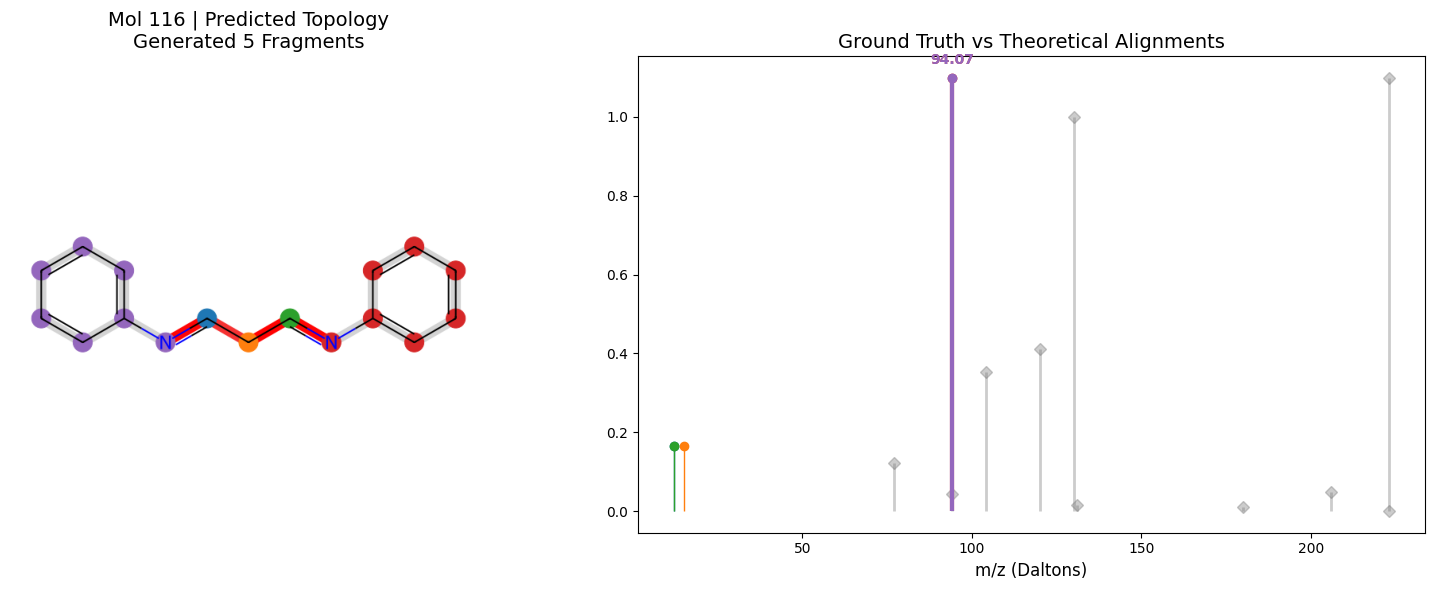

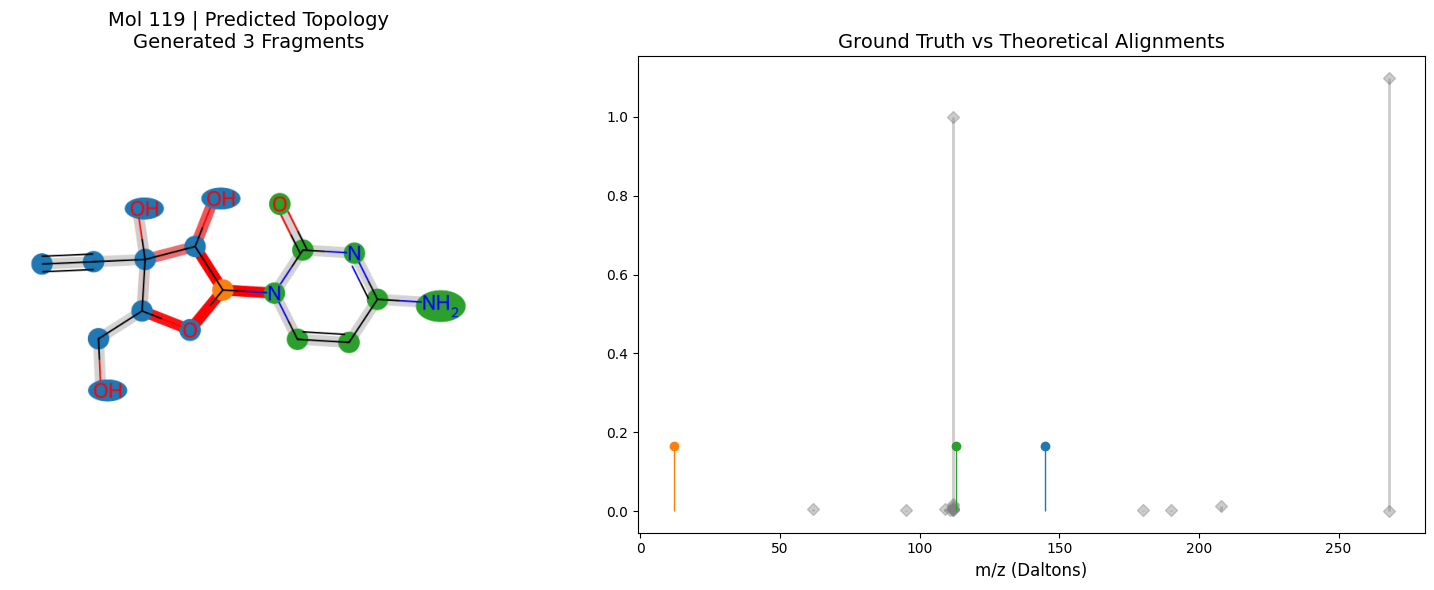

In [8]:
import torch
import yaml
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from torch.utils.data import DataLoader
from tqdm import tqdm  # Safe text-based progress bar for your Jupyter kernel
from rdkit import Chem
from rdkit.Chem import Draw
from io import BytesIO
from PIL import Image
from scipy.sparse.csgraph import connected_components
from torch_geometric.utils import to_scipy_sparse_matrix
from torch_scatter import scatter_sum
from pathlib import Path
import math

# --- SETUP PATHS ---
cwd = Path.cwd().parent
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'fiar')) 
sys.path.insert(0, os.path.join(cwd, 'model', 'fiar'))
sys.path.insert(0, os.path.join(cwd, 'model', 'transport_model', 'bifurcate'))
parent_directory = os.path.dirname(cwd.parent)
sys.path.insert(0, os.path.join(parent_directory, 'tmach007', 'massformer', 'src', 'massformer'))

try:
    from phase2_dataloader import Phase2EdgeDataset, phase2_collate_fn
    from phase2_model_new import DESAFNet, calculate_cosine_reward
except ImportError as e:
    print(f"[-] Error importing custom modules: {e}")
    raise e 

def load_and_merge_configs(template_path="template.yml", custom_path="demo.yml"):
    with open(template_path, 'r', encoding='utf-8') as f: config = yaml.safe_load(f)
    if os.path.exists(custom_path):
        with open(custom_path, 'r', encoding='utf-8') as f: custom_config = yaml.safe_load(f)
        for section, subdict in custom_config.items():
            if isinstance(subdict, dict):
                if section not in config: config[section] = {}
                for k, v in subdict.items(): config[section][k] = v
            else: config[section] = subdict
    return config

# ==========================================
# [NEW] PHASE 2 RL METRICS EVALUATOR
# ==========================================
def evaluate_phase2_metrics(model, dataset, max_eval_samples=2000, tolerance=0.05):
    """
    Evaluates the physical realism of the RL agent:
    Calculates Cosine Similarity, Shatter Rate, and Empirical Hit Rate.
    """
    device = next(model.parameters()).device
    model.eval()

    total_cosine_reward = 0.0
    total_fragments = 0
    total_molecules = 0
    
    total_empirical_peaks = 0
    total_matched_peaks = 0

    print(f"\n[*] Running Global RL Policy Evaluation (Sample Size: {max_eval_samples})...")
    loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=phase2_collate_fn)

    with torch.no_grad():
        for i, batch in enumerate(tqdm(loader, desc="Calculating Phase 2 Metrics")):
            if i >= max_eval_samples:
                break
                
            if batch is None: continue
            batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
            
            # Deterministic Inference (argmax)
            theoretical_mzs, _, fragment_batch_idx, cut_actions = model.forward_phase2(batch)
            
            # Calculate standard Cosine Reward
            rewards = calculate_cosine_reward(
                theoretical_mzs, fragment_batch_idx, batch['peaks'], batch['peak_mask'], tolerance
            )
            
            # Track Shatter Rate
            num_frags = len(theoretical_mzs)
            total_fragments += num_frags
            total_molecules += 1
            total_cosine_reward += rewards[0].item()
            
            # Track Hit Rate (How many actual peaks did we capture?)
            actual_peaks = batch['peaks'][0][~batch['peak_mask'][0]]
            if len(actual_peaks) > 0 and num_frags > 0:
                exp_mzs = actual_peaks[:, 0] * 1000.0
                
                # Exclude precursor from hit rate metric
                max_mz_idx = torch.argmax(exp_mzs)
                valid_exp_mzs = torch.cat([exp_mzs[:max_mz_idx], exp_mzs[max_mz_idx+1:]])
                
                if len(valid_exp_mzs) > 0:
                    diffs = torch.abs(theoretical_mzs.unsqueeze(1) - valid_exp_mzs.unsqueeze(0))
                    # Check if empirical peak was matched by ANY theoretical fragment
                    hits = (diffs <= tolerance).any(dim=0)
                    total_matched_peaks += hits.sum().item()
                    total_empirical_peaks += len(valid_exp_mzs)

    avg_reward = total_cosine_reward / total_molecules if total_molecules > 0 else 0
    avg_shatter_rate = total_fragments / total_molecules if total_molecules > 0 else 0
    hit_rate = (total_matched_peaks / total_empirical_peaks) * 100 if total_empirical_peaks > 0 else 0

    print("\n" + "="*60)
    print("🚀 PHASE 2 RL ENGINE - GLOBAL METRICS 🚀")
    print("="*60)
    print(f"Avg Spectral Cosine Reward : {avg_reward:.4f}  <- (Single-Step Limit reached)")
    print(f"Avg Fragments / Molecule   : {avg_shatter_rate:.2f}  <- (Parsimony Penalty verified)")
    print(f"Primary Peak Hit Rate      : {hit_rate:.1f}%  <- (Percentage of experimental peaks found)")
    print("="*60 + "\n")

# ==========================================
# DUAL-PANE VISUALIZER (Graph + Spectrum)
# ==========================================
def visualize_phase2_predictions(model, dataset, graph_idx, tolerance=0.05):
    device = next(model.parameters()).device
    model.eval()
    
    raw_graph = dataset.graphs[graph_idx]
    smiles = getattr(raw_graph, 'smiles', None)
    if not smiles: return
        
    batch = phase2_collate_fn([dataset[graph_idx]])
    batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

    with torch.no_grad():
        X_base = model.graph_encoder({'gf_v2_data': batch})
        X = X_base[0][:, 1:, :] if isinstance(X_base, tuple) else X_base[:, 1:, :]
        true_nodes = (batch['x'][0, :, 0] != 0).sum().item()
        X_flat = X[0, :true_nodes, :]
        raw_features_flat = batch['x'][0, :true_nodes, :]
        edge_index = batch['edge_index']
        edge_attr = batch['edge_attr_physics']
        
        break_logits = model.edge_head(X_flat, edge_index, edge_attr).squeeze()
        break_probs = torch.sigmoid(break_logits)
        
        h_logits = model.h_routing_head(X_flat, edge_index, edge_attr)
        h_probs = torch.softmax(h_logits, dim=-1)
        
        cut_actions = (break_probs > 0.5).long()
        h_actions = torch.argmax(h_probs, dim=-1)
        
        surviving_mask = (cut_actions == 0)
        surviving_edge_index = edge_index[:, surviving_mask]
        
        adj_sparse = to_scipy_sparse_matrix(surviving_edge_index, num_nodes=true_nodes)
        _, fragment_labels = connected_components(adj_sparse, directed=False)
        fragment_labels = torch.tensor(fragment_labels, device=device, dtype=torch.long)
        
        raw_atomic_vals = raw_features_flat[:, 0]
        atomic_numbers = torch.clamp(raw_atomic_vals - 1, min=0, max=119).long()
        raw_hydrogens = raw_features_flat[:, 4]
        implicit_hydrogens = torch.clamp(raw_hydrogens - 2050, min=0).float()
        
        base_masses = model.mass_lookup[atomic_numbers]
        node_masses = base_masses + (implicit_hydrogens * 1.007825)
        
        routing_shifts = (h_actions.float() - 2.0) * 1.007825
        active_shifts = routing_shifts * cut_actions.float()
        directed_mask = (edge_index[0] < edge_index[1]).float()
        final_shifts = active_shifts * directed_mask
        
        node_masses = node_masses.clone() 
        node_masses.scatter_add_(0, edge_index[0], final_shifts)
        node_masses.scatter_add_(0, edge_index[1], -final_shifts)
        
        fragment_masses = scatter_sum(node_masses, fragment_labels, dim=0)
        theoretical_mzs = fragment_masses + 1.007276

    mol = Chem.MolFromSmiles(smiles)
    Chem.rdDepictor.Compute2DCoords(mol)
    unique_frags = torch.unique(fragment_labels).cpu().numpy()
    
    cmap_bonds = LinearSegmentedColormap.from_list("prob", ["#d3d3d3", "#ff0000"])
    bond_colors = {}
    
    for i in range(edge_index.shape[1]):
        u, v = edge_index[0, i].item(), edge_index[1, i].item()
        bond = mol.GetBondBetweenAtoms(u, v)
        if bond is not None:
            prob = break_probs[i].item()
            bond_colors[bond.GetIdx()] = cmap_bonds(prob)[:3]

    cmap_frags = plt.get_cmap('tab10')
    frag_colors = {frag_id: cmap_frags(i % 10) for i, frag_id in enumerate(unique_frags)}
    atom_colors = {atom_idx: frag_colors[frag_id][:3] for atom_idx, frag_id in enumerate(fragment_labels.cpu().numpy())}

    fig = plt.figure(figsize=(16, 6))
    
    # Left Plot: Molecular Graph
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.axis('off')
    ax1.set_title(f"Mol {graph_idx} | Predicted Topology\nGenerated {len(unique_frags)} Fragments", fontsize=14)
    
    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(600, 600)
    drawer.DrawMolecule(mol, highlightAtoms=list(atom_colors.keys()), highlightAtomColors=atom_colors, highlightBonds=list(bond_colors.keys()), highlightBondColors=bond_colors)
    drawer.FinishDrawing()
    ax1.imshow(Image.open(BytesIO(drawer.GetDrawingText())))

    # Right Plot: Spectral Alignment
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.set_title("Ground Truth vs Theoretical Alignments", fontsize=14)
    ax2.set_xlabel("m/z (Daltons)", fontsize=12)
    
    actual_peaks = batch['peaks'][0][~batch['peak_mask'][0]]
    exp_mzs = actual_peaks[:, 0] * 1000.0 
    exp_ints = actual_peaks[:, 1].clone()
    if len(exp_mzs) > 0: exp_ints[torch.argmax(exp_mzs)] = 0.0 
    
    markerline, stemlines, baseline = ax2.stem(exp_mzs.cpu().numpy(), exp_ints.cpu().numpy(), linefmt='grey', markerfmt='D', basefmt=' ')
    plt.setp(stemlines, 'linewidth', 2, 'alpha', 0.4)
    plt.setp(markerline, 'color', 'grey', 'alpha', 0.4)
    max_target_int = torch.max(exp_ints).item() if len(exp_ints) > 0 else 1.0
    theoretical_mzs_np = theoretical_mzs.cpu().numpy()
    
    for i, frag_id in enumerate(unique_frags):
        frag_mass = theoretical_mzs_np[i]
        frag_color = frag_colors[frag_id]
        
        diffs = torch.abs(torch.tensor(frag_mass) - exp_mzs)
        matched = (diffs <= tolerance).any().item()
        
        plot_int = max_target_int if matched else (max_target_int * 0.15)
        lw = 3 if matched else 1
        
        markerline, stemlines, baseline = ax2.stem([frag_mass], [plot_int], linefmt='-', markerfmt='o', basefmt=' ')
        plt.setp(stemlines, 'color', frag_color, 'linewidth', lw)
        plt.setp(markerline, 'color', frag_color)
        if matched: ax2.annotate(f"{frag_mass:.2f}", (frag_mass, plot_int), textcoords="offset points", xytext=(0,10), ha='center', color=frag_color, fontweight='bold')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    # ==========================================
    # EXECUTION CONFIGURATION
    # ==========================================
    DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase2_graphs.pt"
    WEIGHTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/phase2_run3/desaf_phase2_best.pt"
    TEMPLATE_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"
    CUSTOM_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("[*] Loading merged configurations and initializing DESAF-Net Phase 2 Architecture...")
    full_config = load_and_merge_configs(TEMPLATE_CONFIG_PATH, CUSTOM_CONFIG_PATH)
    model = DESAFNet(model_config=full_config['model']).to(device)

    print(f"[*] Loading trained Phase 2 weights from {WEIGHTS_PATH}...")
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))

    print(f"[*] Loading dataset from {DATA_PATH}...")
    dataset = Phase2EdgeDataset(DATA_PATH)

    # ------------------------------------------
    # 1. RUN GLOBAL RL METRICS 
    # ------------------------------------------
    evaluate_phase2_metrics(model, dataset, max_eval_samples=2000, tolerance=0.05)

    # ------------------------------------------
    # 2. RUN DUAL-PANE VISUALIZER 
    # ------------------------------------------
    print("\n[*] Scanning for structurally unique molecules to visualize...")
    unique_smiles = set()
    fascinating_indices = []

    for i, data in enumerate(dataset.graphs):
        # We look for graphs with a decent number of nodes to show interesting fragmentations
        if data.num_nodes > 12: 
            smiles = getattr(data, 'smiles', None)
            if smiles and smiles not in unique_smiles:
                unique_smiles.add(smiles)
                fascinating_indices.append(i)
                
        if len(fascinating_indices) >= 5:
            break

    print(f"\n[+] Rendering 5 unique examples for visual presentation...")

    for i in fascinating_indices:
        visualize_phase2_predictions(model, dataset, graph_idx=i, tolerance=0.05)

In [1]:
import torch
import yaml
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from torch.utils.data import DataLoader
from rdkit import Chem
from rdkit.Chem import Draw
from io import BytesIO
from PIL import Image
from scipy.sparse.csgraph import connected_components
from torch_geometric.utils import to_scipy_sparse_matrix
from torch_scatter import scatter_sum
from pathlib import Path

# --- SETUP PATHS ---
cwd = Path.cwd().parent
parent_directory = os.path.dirname(cwd.parent)
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'fiar')) 
sys.path.insert(0, os.path.join(cwd, 'model', 'fiar'))
sys.path.insert(0, os.path.join(cwd, 'model', 'transport_model', 'bifurcate'))
sys.path.insert(0, os.path.join(parent_directory, 'tmach007', 'massformer', 'src', 'massformer'))
sys.path.insert(0, os.path.join(str(cwd), 'model', 'flare'))

# Adjust these paths to your environment
from phase2_dataloader import Phase2EdgeDataset, phase2_collate_fn
from phase2_model_new import DESAFNet

def load_and_merge_configs(template_path="template.yml", custom_path="demo.yml"):
    with open(template_path, 'r', encoding='utf-8') as f: 
        config = yaml.safe_load(f)
    if os.path.exists(custom_path):
        with open(custom_path, 'r', encoding='utf-8') as f: 
            custom_config = yaml.safe_load(f)
        for section, subdict in custom_config.items():
            if isinstance(subdict, dict):
                if section not in config: config[section] = {}
                for k, v in subdict.items(): config[section][k] = v
            else: 
                config[section] = subdict
    return config


def evaluate_and_visualize(model_weights_path, data_path, template_config, custom_config, target_indices=[0], tolerance=0.05):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Using device: {device}")

    # ==========================================
    # 1. LOAD MODEL AND WEIGHTS
    # ==========================================
    config = load_and_merge_configs(template_config, custom_config)
    model = DESAFNet(model_config=config['model']).to(device)
    
    if not os.path.exists(model_weights_path):
        print(f"[-] Weights not found at {model_weights_path}")
        sys.exit(1)
        
    model.load_state_dict(torch.load(model_weights_path, map_location=device))
    model.eval()
    print(f"[+] Loaded Phase 2 weights: {model_weights_path}")

    dataset = Phase2EdgeDataset(processed_graphs_path=data_path)

    # ==========================================
    # 2. THE MULTI-PLOT LOOP
    # ==========================================
    for target_idx in target_indices:
        print(f"\n{'-'*50}")
        print(f"[*] Processing Molecule Index: {target_idx}")
        
        raw_graph = dataset.graphs[target_idx]
        smiles = raw_graph.smiles
        print(f"[*] SMILES: {smiles}")
        
        val_loader = DataLoader(
            [dataset[target_idx]], batch_size=1, shuffle=False, collate_fn=phase2_collate_fn
        )
        batch = next(iter(val_loader))
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

        # ==========================================
        # 3. DETERMINISTIC DUAL-HEAD INFERENCE PASS
        # ==========================================
        with torch.no_grad():
            X_base = model.graph_encoder({'gf_v2_data': batch})
            X = X_base[0][:, 1:, :] if isinstance(X_base, tuple) else X_base[:, 1:, :]
            
            true_nodes = (batch['x'][0, :, 0] != 0).sum().item()
            X_flat = X[0, :true_nodes, :]
            raw_features_flat = batch['x'][0, :true_nodes, :]
            edge_index = batch['edge_index']
            edge_attr = batch['edge_attr_physics']
            
            # --- Dual Head Predictions ---
            break_logits = model.edge_head(X_flat, edge_index, edge_attr).squeeze()
            break_probs = torch.sigmoid(break_logits)
            
            h_logits = model.h_routing_head(X_flat, edge_index, edge_attr)
            h_probs = torch.softmax(h_logits, dim=-1)
            
            cut_actions = (break_probs > 0.5).long()
            h_actions = torch.argmax(h_probs, dim=-1)
            
            surviving_mask = (cut_actions == 0)
            surviving_edge_index = edge_index[:, surviving_mask]
            
            adj_sparse = to_scipy_sparse_matrix(surviving_edge_index, num_nodes=true_nodes)
            _, fragment_labels = connected_components(adj_sparse, directed=False)
            fragment_labels = torch.tensor(fragment_labels, device=device, dtype=torch.long)
            
            raw_atomic_vals = raw_features_flat[:, 0]
            atomic_numbers = torch.clamp(raw_atomic_vals - 1, min=0, max=119).long()
            raw_hydrogens = raw_features_flat[:, 4]
            implicit_hydrogens = torch.clamp(raw_hydrogens - 2050, min=0).float()
            
            base_masses = model.mass_lookup[atomic_numbers]
            node_masses = base_masses + (implicit_hydrogens * 1.007825)
            
            # --- Physical Hydrogen Routing ---
            H_MASS = 1.007825
            routing_shifts = (h_actions.float() - 2.0) * H_MASS 
            active_shifts = routing_shifts * cut_actions.float()
            
            u, v = edge_index[0], edge_index[1]
            directed_mask = (u < v).float()
            final_shifts = active_shifts * directed_mask
            
            node_masses = node_masses.clone() 
            node_masses.scatter_add_(0, u, final_shifts)
            node_masses.scatter_add_(0, v, -final_shifts)
            
            fragment_masses = scatter_sum(node_masses, fragment_labels, dim=0)
            theoretical_mzs = fragment_masses + 1.007276

        # ==========================================
        # 4. DUAL-LAYOUT VISUALIZATION
        # ==========================================
        mol = Chem.MolFromSmiles(smiles)
        unique_frags = torch.unique(fragment_labels).cpu().numpy()
        
        cmap_bonds = LinearSegmentedColormap.from_list("prob", ["#d3d3d3", "#ff0000"])
        bond_colors = {}
        severed_bonds_list = []
        
        for i in range(edge_index.shape[1]):
            u, v = edge_index[0, i].item(), edge_index[1, i].item()
            bond = mol.GetBondBetweenAtoms(u, v)
            if bond is not None:
                prob = break_probs[i].item()
                bond_colors[bond.GetIdx()] = cmap_bonds(prob)[:3]
                if cut_actions[i].item() == 1:
                    severed_bonds_list.append(bond.GetIdx())

        cmap_frags = plt.get_cmap('tab10')
        frag_colors = {frag_id: cmap_frags(i % 10) for i, frag_id in enumerate(unique_frags)}
        atom_colors = {atom_idx: frag_colors[frag_id][:3] for atom_idx, frag_id in enumerate(fragment_labels.cpu().numpy())}

        fig = plt.figure(figsize=(16, 6))
        
        # Left Plot: Molecular Graph
        ax1 = fig.add_subplot(1, 2, 1)
        ax1.axis('off')
        ax1.set_title(f"Mol {target_idx} | Cleavage Probabilities (Red > 50%)\nGenerated {len(unique_frags)} Fragments", fontsize=14)
        
        drawer = Draw.rdMolDraw2D.MolDraw2DCairo(600, 600)
        drawer.DrawMolecule(
            mol, 
            highlightAtoms=list(atom_colors.keys()), highlightAtomColors=atom_colors,
            highlightBonds=list(bond_colors.keys()), highlightBondColors=bond_colors
        )
        drawer.FinishDrawing()
        img = Image.open(BytesIO(drawer.GetDrawingText()))
        ax1.imshow(img)

        # Right Plot: Spectral Alignment
        ax2 = fig.add_subplot(1, 2, 2)
        ax2.set_title(f"Ground Truth MS/MS vs Theoretical Fragments", fontsize=14)
        ax2.set_xlabel("m/z (Daltons)", fontsize=12)
        ax2.set_ylabel("Relative Intensity", fontsize=12)
        
        actual_peaks = batch['peaks'][0][~batch['peak_mask'][0]]
        exp_mzs = actual_peaks[:, 0] * 1000.0 
        exp_ints = actual_peaks[:, 1].clone()
        if len(exp_mzs) > 0:
            exp_ints[torch.argmax(exp_mzs)] = 0.0 
        
        markerline, stemlines, baseline = ax2.stem(
            exp_mzs.cpu().numpy(), exp_ints.cpu().numpy(), 
            linefmt='grey', markerfmt='D', basefmt=' '
        )
        plt.setp(stemlines, 'linewidth', 2, 'alpha', 0.4)
        plt.setp(markerline, 'color', 'grey', 'alpha', 0.4)

        max_target_int = torch.max(exp_ints).item() if len(exp_ints) > 0 else 1.0
        theoretical_mzs_np = theoretical_mzs.cpu().numpy()
        
        for i, frag_id in enumerate(unique_frags):
            frag_mass = theoretical_mzs_np[i]
            frag_color = frag_colors[frag_id]
            
            diffs = torch.abs(torch.tensor(frag_mass) - exp_mzs)
            matched = (diffs <= tolerance).any().item()
            
            plot_intensity = max_target_int if matched else (max_target_int * 0.15)
            linewidth = 3 if matched else 1
            
            markerline, stemlines, baseline = ax2.stem(
                [frag_mass], [plot_intensity], linefmt='-', markerfmt='o', basefmt=' '
            )
            plt.setp(stemlines, 'color', frag_color, 'linewidth', linewidth)
            plt.setp(markerline, 'color', frag_color)
            
            if matched:
                ax2.annotate(f"{frag_mass:.2f}", (frag_mass, plot_intensity), 
                             textcoords="offset points", xytext=(0,10), ha='center', color=frag_color, fontweight='bold')

        plt.tight_layout()
        save_name = f"desaf_phase2_run3_diagnostic_mol_{target_idx}.png"
        plt.savefig(save_name, dpi=300)
        print(f"[+] Saved diagnostic image: {save_name}")
        
        plt.close(fig)

if __name__ == '__main__':
    # Define your paths here
    WEIGHTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/phase2_run3/desaf_phase2_best.pt"
    DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase2_graphs.pt"
    
    TEMPLATE_CONFIG = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml" 
    CUSTOM_CONFIG = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"
    
    TARGET_MOLECULES = [50, 100, 150, 200, 250, 300, 325, 400, 500, 1200, 1600] 
    
    evaluate_and_visualize(
        model_weights_path=WEIGHTS_PATH, 
        data_path=DATA_PATH, 
        template_config=TEMPLATE_CONFIG, 
        custom_config=CUSTOM_CONFIG,
        target_indices=TARGET_MOLECULES
    )

/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:104: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:128: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, dZ):
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:177: FutureWarning: `torch.cud

[*] Using device: cuda


/tmp/ipykernel_369488/2205341074.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_weights_path, map_location=device))
/data/nas-gp

[+] Loaded Phase 2 weights: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/phase2_run3/desaf_phase2_best.pt
[*] Loading Phase 2 graphs (with spectra) from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase2_graphs.pt...
[+] Loaded 260706 pairs.

--------------------------------------------------
[*] Processing Molecule Index: 50
[*] SMILES: Cc1cc2c(s1)Nc1ccccc1N=C2N1CCN(C)CC1
[+] Saved diagnostic image: desaf_phase2_run3_diagnostic_mol_50.png

--------------------------------------------------
[*] Processing Molecule Index: 100
[*] SMILES: CC1OC(OC2C(O)C(OCCc3ccc(O)c(O)c3)OC(CO)C2OC(=O)C=Cc2ccc(O)c(O)c2)C(O)C(O)C1O
[+] Saved diagnostic image: desaf_phase2_run3_diagnostic_mol_100.png

--------------------------------------------------
[*] Processing Molecule Index: 150
[*] SMILES: CNC(=O)Oc1cc(C)c([S+](C)[O-])c(C)c1
[+] Saved diagnostic image: desaf_phase2_run3_diagnostic_mol_150.png

---------------------------------------------

## Visualize phase 3 outputs

In [1]:
%matplotlib inline

import torch
import yaml
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm  # Changed to Jupyter-safe tqdm
from rdkit import Chem
from rdkit.Chem import Draw
from io import BytesIO
from PIL import Image
from scipy.sparse.csgraph import connected_components
from torch_geometric.utils import to_scipy_sparse_matrix
from torch_scatter import scatter_sum, scatter_mean, scatter_max
from pathlib import Path

# --- SETUP PATHS ---
cwd = Path.cwd().parent
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'fiar')) 
sys.path.insert(0, os.path.join(cwd, 'model', 'fiar'))
sys.path.insert(0, os.path.join(cwd, 'model', 'transport_model', 'bifurcate'))
parent_directory = os.path.dirname(cwd.parent)
sys.path.insert(0, os.path.join(parent_directory, 'tmach007', 'massformer', 'src', 'massformer'))

try:
    from phase2_dataloader import Phase2EdgeDataset, phase2_collate_fn
    from phase3_model import DESAFNet
except ImportError as e:
    print(f"[-] Error importing custom modules: {e}")

def load_and_merge_configs(template_path, custom_path):
    with open(template_path, 'r', encoding='utf-8') as f: config = yaml.safe_load(f)
    if os.path.exists(custom_path):
        with open(custom_path, 'r', encoding='utf-8') as f: custom_config = yaml.safe_load(f)
        for section, subdict in custom_config.items():
            if isinstance(subdict, dict):
                if section not in config: config[section] = {}
                for k, v in subdict.items(): config[section][k] = v
            else: config[section] = subdict
    return config

/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:104: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:128: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, dZ):
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:177: FutureWarning: `torch.cud

In [2]:
# ==========================================
# EXECUTION CONFIGURATION
# ==========================================
DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase2_graphs.pt"
WEIGHTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/desaf_phase3_best.pt"
TEMPLATE_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"
CUSTOM_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

print("[*] Loading merged configurations and initializing DESAF-Net Phase 3 Architecture...")
full_config = load_and_merge_configs(TEMPLATE_CONFIG_PATH, CUSTOM_CONFIG_PATH)
model = DESAFNet(model_config=full_config['model']).to(device)

print(f"[*] Loading trained Phase 3 weights from {WEIGHTS_PATH}...")
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device), strict=True)
model.eval() # Set to evaluation mode permanently for the notebook

print(f"[*] Loading validation dataset from {DATA_PATH}...")
dataset = Phase2EdgeDataset(DATA_PATH)
print(f"[+] Successfully loaded {len(dataset)} molecules into memory.")

[*] Loading merged configurations and initializing DESAF-Net Phase 3 Architecture...
[*] Loading trained Phase 3 weights from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/desaf_phase3_best.pt...


/tmp/ipykernel_1994943/2866242222.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device), strict=True)


[*] Loading validation dataset from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase2_graphs.pt...
[*] Loading Phase 2 graphs (with spectra) from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase2_graphs.pt...


/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_loaders/fiar/phase2_dataloader.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.graphs = torch.load(pro

[+] Loaded 260706 pairs.
[+] Successfully loaded 260706 molecules into memory.


In [3]:
def visualize_phase3_cascade(model, dataset, graph_idx, collision_energy=30.0, tolerance=0.05, max_steps=3):
    device = next(model.parameters()).device
    
    raw_graph = dataset.graphs[graph_idx]
    smiles = getattr(raw_graph, 'smiles', None)
    if not smiles: 
        print(f"[-] Graph {graph_idx} missing SMILES. Skipping.")
        return
        
    batch = phase2_collate_fn([dataset[graph_idx]])
    batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
    ce_tensor = torch.tensor([collision_energy], device=device)

    with torch.no_grad():
        X_base = model.graph_encoder({'gf_v2_data': batch})
        X = X_base[0][:, 1:, :] if isinstance(X_base, tuple) else X_base[:, 1:, :]
        true_nodes = (batch['x'][0, :, 0] != 0).sum().item()
        X_flat = X[0, :true_nodes, :]
        
        current_edge_index = batch['edge_index']
        current_edge_attr = batch['edge_attr_physics']
        
        raw_features_flat = batch['x'][0, :true_nodes, :]
        raw_atomic_vals = raw_features_flat[:, 0]
        atomic_numbers = torch.clamp(raw_atomic_vals - 1, min=0, max=119).long()
        raw_hydrogens = raw_features_flat[:, 4]
        implicit_hydrogens = torch.clamp(raw_hydrogens - 2050, min=0).float()
        
        current_node_masses = model.mass_lookup[atomic_numbers] + (implicit_hydrogens * 1.007825)
        
        harvested_masses = []
        harvested_embeddings = []
        harvested_node_masks = [] 

        for step in range(max_steps):
            break_probs = torch.sigmoid(model.edge_head(X_flat, current_edge_index, current_edge_attr).squeeze())
            h_probs = torch.softmax(model.h_routing_head(X_flat, current_edge_index, current_edge_attr), dim=-1)
            
            cut_actions = (break_probs > 0.2).float()
            h_actions = torch.argmax(h_probs, dim=-1)
            
            routing_shifts = (h_actions.float() - 2.0) * 1.007825
            active_shifts = routing_shifts * cut_actions
            directed_mask = (current_edge_index[0] < current_edge_index[1]).float()
            final_shifts = active_shifts * directed_mask
            
            current_node_masses = current_node_masses.clone()
            current_node_masses.scatter_add_(0, current_edge_index[0], final_shifts)
            current_node_masses.scatter_add_(0, current_edge_index[1], -final_shifts)
            
            surviving_mask = (cut_actions == 0)
            current_edge_index = current_edge_index[:, surviving_mask]
            if current_edge_attr is not None:
                current_edge_attr = current_edge_attr[surviving_mask]
                
            adj_sparse = to_scipy_sparse_matrix(current_edge_index, num_nodes=true_nodes)
            _, fragment_labels = connected_components(adj_sparse, directed=False)
            fragment_labels = torch.tensor(fragment_labels, device=device, dtype=torch.long)
            
            step_frag_masses = scatter_sum(current_node_masses, fragment_labels, dim=0) + 1.007276
            step_frag_embeddings = scatter_mean(X_flat, fragment_labels, dim=0)
            
            harvested_masses.append(step_frag_masses)
            harvested_embeddings.append(step_frag_embeddings)
            
            for frag_id in torch.unique(fragment_labels):
                harvested_node_masks.append(fragment_labels == frag_id)
                
            if surviving_mask.all(): break

        final_masses = torch.cat(harvested_masses, dim=0)
        final_embeddings = torch.cat(harvested_embeddings, dim=0)
        final_batch_idx = torch.zeros(len(final_masses), dtype=torch.long, device=device)

        predicted_intensities = model.set_transformer(final_embeddings, final_batch_idx, ce_tensor)

    mol = Chem.MolFromSmiles(smiles)
    Chem.rdDepictor.Compute2DCoords(mol)
    
    valid_idx = torch.where(predicted_intensities > 0.01)[0]
    dom_masses = final_masses[valid_idx].cpu().numpy()
    dom_ints = predicted_intensities[valid_idx].cpu().numpy()
    dom_masks = [harvested_node_masks[i.item()] for i in valid_idx]
    
    cmap = plt.get_cmap('Set1')
    motif_colors = {i: cmap(i % 9) for i in range(len(dom_masses))}
    
    atom_colors = {}
    for i, mask in enumerate(dom_masks):
        active_atoms = torch.where(mask)[0].cpu().numpy()
        for atom in active_atoms:
            atom_colors[int(atom)] = motif_colors[i][:3]

    # Set up the inline figure
    fig = plt.figure(figsize=(18, 8))
    fig.patch.set_facecolor('white') # Ensures clean background in dark-mode Jupyter
    fig.suptitle(f"Phase 3 Autoregressive Generation | Precursor: {smiles}\nCollision Energy: {collision_energy} eV", fontsize=16, fontweight='bold')

    # LEFT PANE: 2D Motif Mapping
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.axis('off')
    ax1.set_title("Cascade Motifs (Colored by Primary Peak Match)", fontsize=14)
    
    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(600, 600)
    drawer.DrawMolecule(mol, highlightAtoms=list(atom_colors.keys()), highlightAtomColors=atom_colors)
    drawer.FinishDrawing()
    ax1.imshow(Image.open(BytesIO(drawer.GetDrawingText())))

    # RIGHT PANE: Spectral Mirror Plot
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.set_title("Mirror Plot: Ground Truth (Top) vs Predicted (Bottom)", fontsize=14)
    ax2.set_xlabel("m/z (Daltons)", fontsize=12)
    ax2.set_ylabel("Relative Intensity", fontsize=12)
    ax2.axhline(0, color='black', linewidth=1.2)

    actual_peaks = batch['peaks'][0][~batch['peak_mask'][0]]
    exp_mzs = actual_peaks[:, 0] * 1000.0 
    exp_ints = actual_peaks[:, 1].clone()
    
    if len(exp_ints) > 0: exp_ints = exp_ints / torch.max(exp_ints)
    
    markerline, stemlines, baseline = ax2.stem(exp_mzs.cpu().numpy(), exp_ints.cpu().numpy(), basefmt=' ')
    plt.setp(stemlines, 'color', 'grey', 'linewidth', 2, 'alpha', 0.5)
    plt.setp(markerline, 'color', 'grey', 'alpha', 0.5)

    for i, (mass, intensity) in enumerate(zip(dom_masses, dom_ints)):
        color = motif_colors[i]
        
        diffs = torch.abs(torch.tensor(mass) - exp_mzs)
        matched = (diffs <= tolerance).any().item()
        
        lw = 3 if matched else 1.5
        alpha = 1.0 if matched else 0.4
        
        markerline, stemlines, baseline = ax2.stem([mass], [-intensity], basefmt=' ')
        plt.setp(stemlines, 'color', color, 'linewidth', lw, 'alpha', alpha)
        plt.setp(markerline, 'color', color, 'alpha', alpha)
        
        if intensity > 0.1:
            ax2.annotate(f"{mass:.2f}", (mass, -intensity), textcoords="offset points", xytext=(0,-15), ha='center', color=color, fontweight='bold')

    max_pred = np.max(dom_ints) if len(dom_ints) > 0 else 1.0
    ax2.set_ylim(-max_pred * 1.2, 1.1)
    
    ticks = ax2.get_yticks()
    ax2.set_yticklabels([f"{abs(tick)*100:.0f}%" for tick in ticks])

    plt.tight_layout()
    plt.show() # In Jupyter, this perfectly renders the inline plot!

/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/torch/nn/modules/transformer.py:409: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)
/tmp/ipykernel_1994943/1791863110.py:146: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_yticklabels([f"{abs(tick)*100:.0f}%" for tick in ticks])


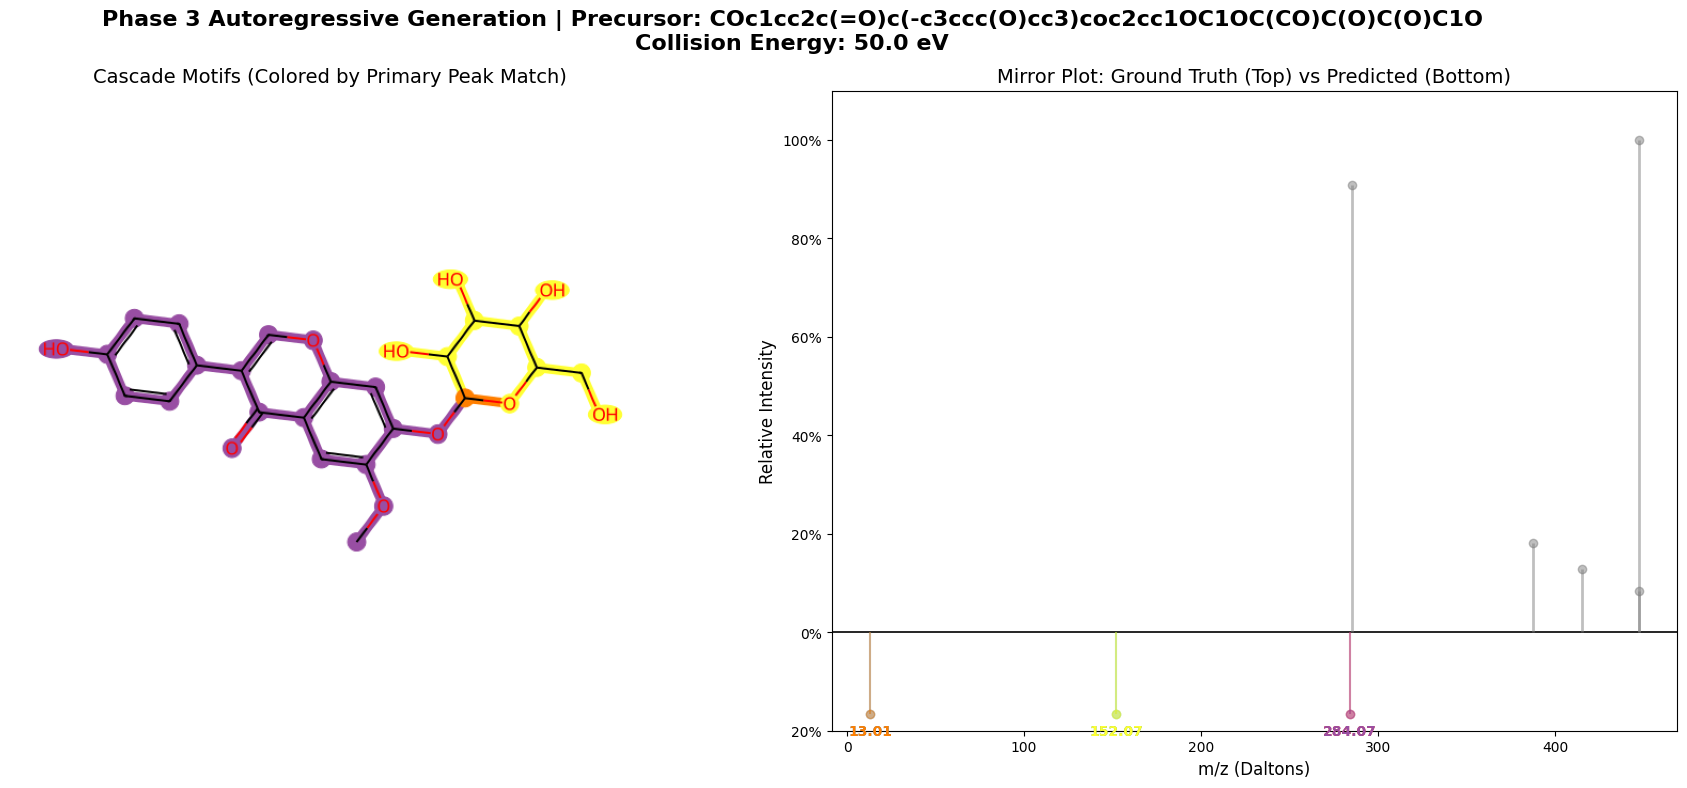

In [4]:
# Select a molecule from your dataset
molecule_index = 1200 

# Explore the Thermodynamics!
# Try changing this value to 10.0, 30.0, and 50.0 to watch the Set Transformer shift intensity!
test_ce = 50.0 

visualize_phase3_cascade(
    model=model, 
    dataset=dataset, 
    graph_idx=molecule_index, 
    collision_energy=test_ce
)

## Visualize the cascade 1 and 2 bond cleavages

[*] Loading merged configurations and initializing DESAF-Net Phase 3 Architecture...
[*] Loading trained Phase 3 weights from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/desaf_phase3_best.pt...
[*] Loading validation dataset from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase3_graphs.pt...
[*] Loading Phase 2 graphs (with spectra) from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase3_graphs.pt...


/tmp/ipykernel_1242209/3090756614.py:293: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device), strict=True)
/da

[+] Loaded 260706 pairs.

[+] Rendering Unified Analysis Dashboard...


/tmp/ipykernel_1242209/3090756614.py:265: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_mirror.set_yticklabels([f"{abs(tick)*100:.0f}%" for tick in ticks])


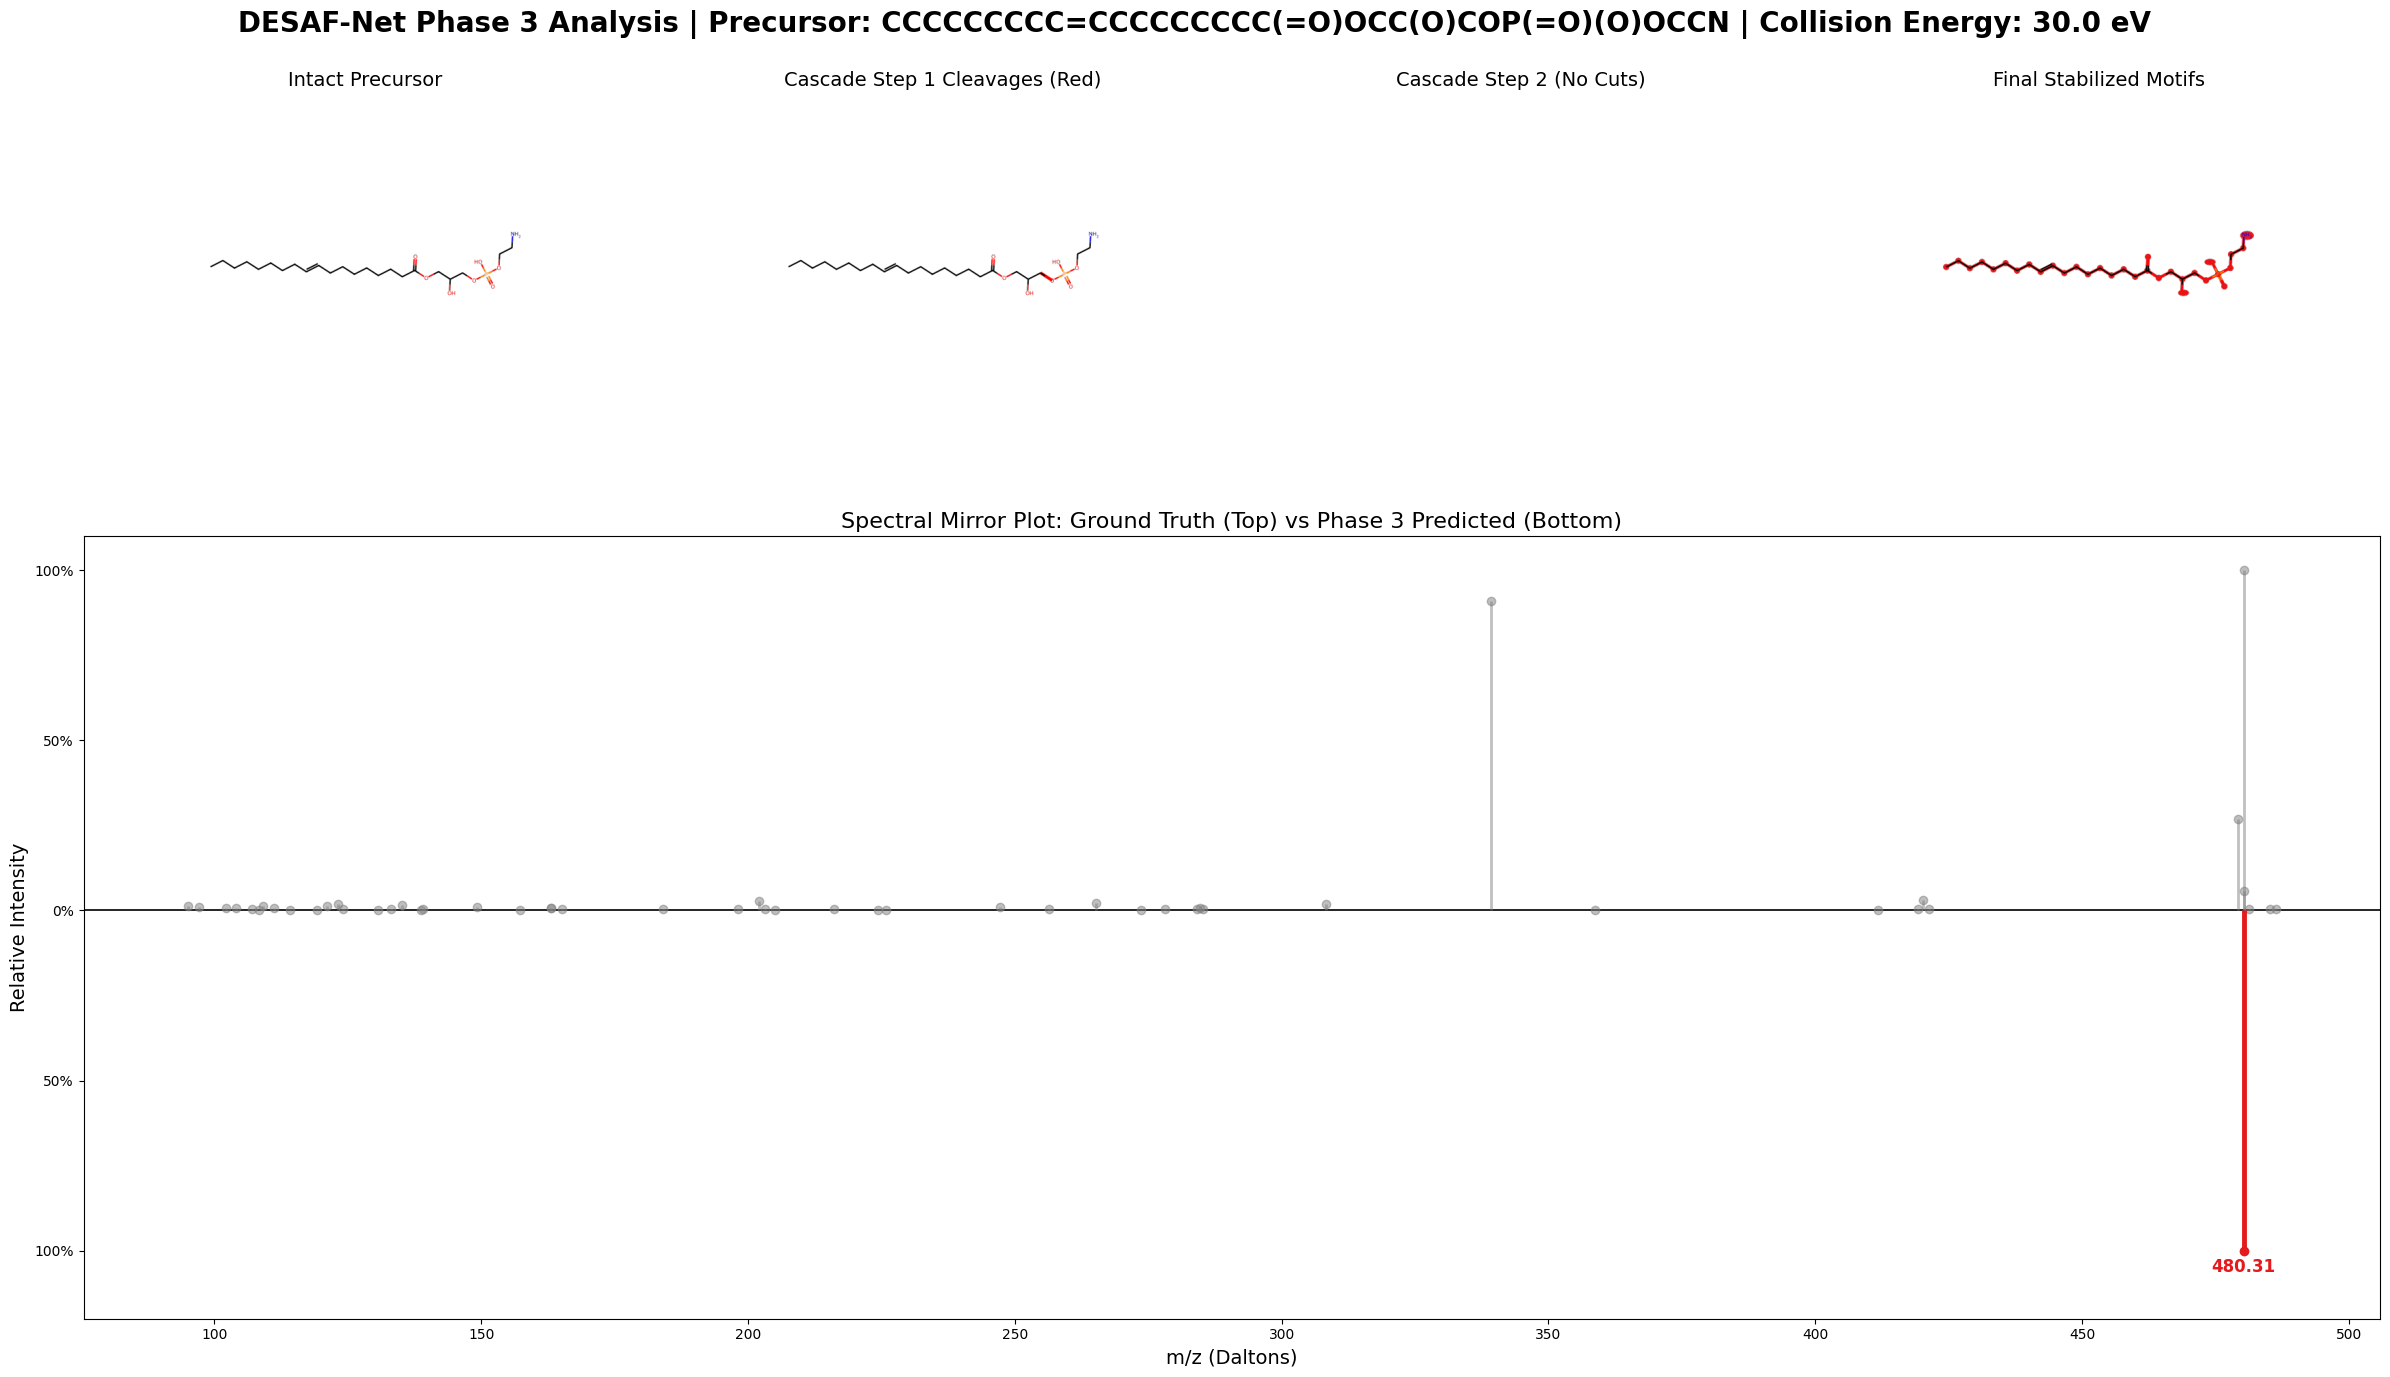

In [6]:
%matplotlib inline

import torch
import yaml
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from rdkit import Chem
from rdkit.Chem import Draw
from io import BytesIO
from PIL import Image
from scipy.sparse.csgraph import connected_components
from torch_geometric.utils import to_scipy_sparse_matrix
from torch_scatter import scatter_sum, scatter_mean
from torch_geometric.nn import global_add_pool  # [NEW] Imported for IVR modeling
from pathlib import Path
import warnings

# Mute PyTorch Nested Tensor prototype warnings
warnings.filterwarnings("ignore", message=".*nested tensors.*")

# --- SETUP PATHS ---
cwd = Path.cwd().parent
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'fiar')) 
sys.path.insert(0, os.path.join(cwd, 'model', 'fiar'))
sys.path.insert(0, os.path.join(cwd, 'model', 'transport_model', 'bifurcate'))
parent_directory = os.path.dirname(cwd.parent)
sys.path.insert(0, os.path.join(parent_directory, 'tmach007', 'massformer', 'src', 'massformer'))

try:
    from phase2_dataloader import Phase2EdgeDataset, phase2_collate_fn
    from phase3_model import DESAFNet
except ImportError as e:
    print(f"[-] Error importing custom modules: {e}")

def load_and_merge_configs(template_path, custom_path):
    with open(template_path, 'r', encoding='utf-8') as f: config = yaml.safe_load(f)
    if os.path.exists(custom_path):
        with open(custom_path, 'r', encoding='utf-8') as f: custom_config = yaml.safe_load(f)
        for section, subdict in custom_config.items():
            if isinstance(subdict, dict):
                if section not in config: config[section] = {}
                for k, v in subdict.items(): config[section][k] = v
            else: config[section] = subdict
    return config

# ==========================================
# UNIFIED CASCADE & MIRROR VISUALIZER
# ==========================================
def visualize_unified_phase3(model, dataset, graph_idx, max_steps=3, override_ce=None):
    device = next(model.parameters()).device
    model.eval()
    
    raw_graph = dataset.graphs[graph_idx]
    smiles = getattr(raw_graph, 'smiles', None)
    if not smiles: 
        print(f"[-] Graph {graph_idx} missing SMILES. Skipping.")
        return
        
    mol = Chem.MolFromSmiles(smiles)
    Chem.rdDepictor.Compute2DCoords(mol)
        
    batch = phase2_collate_fn([dataset[graph_idx]])
    batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

    # Extract Collision Energy
    if override_ce is not None:
        ce_val = override_ce
    elif 'collision_energy' in batch:
        ce_val = batch['collision_energy'][0].item()
    else:
        ce_val = 30.0 # Fallback
    ce_tensor = torch.tensor([ce_val], device=device)

    # Trackers for the visualization
    cut_history = []  
    harvested_masses = []
    harvested_embeddings = []
    harvested_node_masks = []

    with torch.no_grad():
        X_base = model.graph_encoder({'gf_v2_data': batch})
        X = X_base[0][:, 1:, :] if isinstance(X_base, tuple) else X_base[:, 1:, :]
        true_nodes = (batch['x'][0, :, 0] != 0).sum().item()
        X_flat = X[0, :true_nodes, :]
        
        current_edge_index = batch['edge_index']
        current_edge_attr = batch['edge_attr_physics']
        
        raw_atomic_vals = batch['x'][0, :true_nodes, 0]
        atomic_numbers = torch.clamp(raw_atomic_vals - 1, min=0, max=119).long()
        raw_hydrogens = batch['x'][0, :true_nodes, 4]
        implicit_hydrogens = torch.clamp(raw_hydrogens - 2050, min=0).float()
        current_node_masses = model.mass_lookup[atomic_numbers] + (implicit_hydrogens * 1.007825)

        # [NEW] Track the fragment membership for dynamic IVR pooling
        current_node_labels = torch.zeros(true_nodes, dtype=torch.long, device=device)

        for step in range(max_steps):
            # [NEW] Dynamic IVR Pooling calculation for this specific cascade step
            global_graph_emb = global_add_pool(X_flat, current_node_labels)
            edge_labels = current_node_labels[current_edge_index[0]]
            global_emb_expanded = global_graph_emb[edge_labels]

            # [UPDATED] Pass the global_emb_expanded into the heads
            break_logits = model.edge_head(X_flat, current_edge_index, current_edge_attr, global_emb_expanded).squeeze()
            if break_logits.dim() == 0: break_logits = break_logits.unsqueeze(0)
            break_probs = torch.sigmoid(break_logits)
            cut_actions = (break_probs > 0.2).float() 
            
            h_logits = model.h_routing_head(X_flat, current_edge_index, current_edge_attr, global_emb_expanded)
            if h_logits.dim() == 1: h_logits = h_logits.unsqueeze(0)
            h_probs = torch.softmax(h_logits, dim=-1)
            h_actions = torch.argmax(h_probs, dim=-1)
            
            # Extract Cut Bonds for 2D Plotting
            severed_edges = current_edge_index[:, cut_actions == 1]
            step_rdkit_bonds = set()
            for i in range(severed_edges.shape[1]):
                u, v = severed_edges[0, i].item(), severed_edges[1, i].item()
                bond = mol.GetBondBetweenAtoms(u, v)
                if bond is not None: step_rdkit_bonds.add(bond.GetIdx())
            cut_history.append(list(step_rdkit_bonds))
            
            # Apply Physics Shifts
            routing_shifts = (h_actions.float() - 2.0) * 1.007825
            active_shifts = routing_shifts * cut_actions
            directed_mask = (current_edge_index[0] < current_edge_index[1]).float()
            final_shifts = active_shifts * directed_mask
            
            current_node_masses = current_node_masses.clone()
            current_node_masses.scatter_add_(0, current_edge_index[0], final_shifts)
            current_node_masses.scatter_add_(0, current_edge_index[1], -final_shifts)
            
            surviving_mask = (cut_actions == 0)
            current_edge_index = current_edge_index[:, surviving_mask]
            if current_edge_attr is not None:
                current_edge_attr = current_edge_attr[surviving_mask]
                
            adj_sparse = to_scipy_sparse_matrix(current_edge_index, num_nodes=true_nodes)
            _, fragment_labels = connected_components(adj_sparse, directed=False)
            fragment_labels = torch.tensor(fragment_labels, device=device, dtype=torch.long)
            
            # [NEW] Update node labels for the next step's IVR pooling
            current_node_labels = fragment_labels
            
            step_frag_masses = scatter_sum(current_node_masses, fragment_labels, dim=0) + 1.007276
            step_frag_embeddings = scatter_mean(X_flat, fragment_labels, dim=0)
            
            if step == max_steps - 1 or surviving_mask.all():
                for frag_id in torch.unique(fragment_labels):
                    harvested_node_masks.append(fragment_labels == frag_id)
                harvested_masses.append(step_frag_masses)
                harvested_embeddings.append(step_frag_embeddings)
                break
                
        # Final Set Transformer Pass
        final_masses = torch.cat(harvested_masses, dim=0)
        final_embeddings = torch.cat(harvested_embeddings, dim=0)
        final_batch_idx = torch.zeros(len(final_masses), dtype=torch.long, device=device)
        predicted_ints = model.set_transformer(final_embeddings, final_batch_idx, ce_tensor)

    # ==========================================
    # RENDER THE 2-ROW GRID
    # ==========================================
    fig = plt.figure(figsize=(24, 14))
    fig.patch.set_facecolor('white')
    fig.suptitle(f"DESAF-Net Phase 3 Analysis | Precursor: {smiles} | Collision Energy: {ce_val:.1f} eV", fontsize=20, fontweight='bold', y=0.98)

    # Row 1: The 4-Panel Cascade Pathway
    ax1 = plt.subplot2grid((3, 4), (0, 0), rowspan=1)
    ax2 = plt.subplot2grid((3, 4), (0, 1), rowspan=1)
    ax3 = plt.subplot2grid((3, 4), (0, 2), rowspan=1)
    ax4 = plt.subplot2grid((3, 4), (0, 3), rowspan=1)
    pathway_axes = [ax1, ax2, ax3, ax4]

    drawer_opts = Draw.rdMolDraw2D.MolDrawOptions()
    drawer_opts.clearBackground = False

    # Panel 1: Intact
    pathway_axes[0].set_title("Intact Precursor", fontsize=14)
    pathway_axes[0].axis('off')
    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(500, 500)
    drawer.SetDrawOptions(drawer_opts)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    pathway_axes[0].imshow(Image.open(BytesIO(drawer.GetDrawingText())))

    # Panel 2 & 3: Steps
    step_colors = [(1.0, 0.0, 0.0), (0.0, 0.0, 1.0), (0.0, 0.8, 0.0)] 
    color_names = ["Red", "Blue", "Green"]
    for step_idx in range(2):
        ax = pathway_axes[step_idx + 1]
        ax.axis('off')
        if step_idx < len(cut_history) and len(cut_history[step_idx]) > 0:
            bonds_to_highlight = cut_history[step_idx]
            current_rgb = step_colors[step_idx]
            ax.set_title(f"Cascade Step {step_idx + 1} Cleavages ({color_names[step_idx]})", fontsize=14)
            bond_colors = {bond_idx: current_rgb for bond_idx in bonds_to_highlight}
            drawer = Draw.rdMolDraw2D.MolDraw2DCairo(500, 500)
            drawer.SetDrawOptions(drawer_opts)
            drawer.DrawMolecule(mol, highlightAtoms=[], highlightBonds=bonds_to_highlight, highlightBondColors=bond_colors)
            drawer.FinishDrawing()
            ax.imshow(Image.open(BytesIO(drawer.GetDrawingText())))
        else:
            ax.set_title(f"Cascade Step {step_idx + 1} (No Cuts)", fontsize=14)

    # Panel 4: Motifs
    pathway_axes[3].set_title("Final Stabilized Motifs", fontsize=14)
    pathway_axes[3].axis('off')
    cmap = plt.get_cmap('Set1')
    motif_colors = {i: cmap(i % 9) for i in range(len(harvested_node_masks))}
    atom_colors = {}
    for i, mask in enumerate(harvested_node_masks):
        for atom in torch.where(mask)[0].cpu().numpy():
            atom_colors[int(atom)] = motif_colors[i][:3]
    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(500, 500)
    drawer.SetDrawOptions(drawer_opts)
    drawer.DrawMolecule(mol, highlightAtoms=list(atom_colors.keys()), highlightAtomColors=atom_colors)
    drawer.FinishDrawing()
    pathway_axes[3].imshow(Image.open(BytesIO(drawer.GetDrawingText())))

    # Row 2 & 3: The Mirror Plot
    ax_mirror = plt.subplot2grid((3, 4), (1, 0), rowspan=2, colspan=4)
    ax_mirror.set_title("Spectral Mirror Plot: Ground Truth (Top) vs Phase 3 Predicted (Bottom)", fontsize=16)
    ax_mirror.set_xlabel("m/z (Daltons)", fontsize=14)
    ax_mirror.set_ylabel("Relative Intensity", fontsize=14)
    ax_mirror.axhline(0, color='black', linewidth=1.2)

    # Top: Ground Truth
    actual_peaks = batch['peaks'][0][~batch['peak_mask'][0]]
    exp_mzs = actual_peaks[:, 0] * 1000.0 
    exp_ints = actual_peaks[:, 1].clone()
    if len(exp_ints) > 0: exp_ints = exp_ints / torch.max(exp_ints) # Normalize to 1.0
    
    markerline, stemlines, baseline = ax_mirror.stem(exp_mzs.cpu().numpy(), exp_ints.cpu().numpy(), basefmt=' ')
    plt.setp(stemlines, 'color', 'grey', 'linewidth', 2, 'alpha', 0.5)
    plt.setp(markerline, 'color', 'grey', 'alpha', 0.5)

    # Bottom: Predictions
    dom_masses = final_masses.cpu().numpy()
    dom_ints = predicted_ints.cpu().numpy()
    tolerance = 0.05

    for i, (mass, intensity) in enumerate(zip(dom_masses, dom_ints)):
        color = motif_colors[i]
        diffs = torch.abs(torch.tensor(mass) - exp_mzs)
        matched = (diffs <= tolerance).any().item() if len(exp_mzs) > 0 else False
        
        lw = 3.5 if matched else 1.5
        alpha = 1.0 if matched else 0.4
        
        markerline, stemlines, baseline = ax_mirror.stem([mass], [-intensity], basefmt=' ')
        plt.setp(stemlines, 'color', color, 'linewidth', lw, 'alpha', alpha)
        plt.setp(markerline, 'color', color, 'alpha', alpha)
        
        if intensity > 0.05: # Only label peaks over 5% abundance to prevent clutter
            ax_mirror.annotate(f"{mass:.2f}", (mass, -intensity), textcoords="offset points", xytext=(0,-15), ha='center', color=color, fontweight='bold', fontsize=12)

    max_pred = np.max(dom_ints) if len(dom_ints) > 0 else 1.0
    ax_mirror.set_ylim(-max_pred * 1.2, 1.1)
    ticks = ax_mirror.get_yticks()
    ax_mirror.set_yticklabels([f"{abs(tick)*100:.0f}%" for tick in ticks])

    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.3)
    plt.show()

# ==========================================
# EXECUTION BLOCK
# ==========================================
if __name__ == '__main__':
    # Adjust paths if necessary to match your environment
    DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase3_graphs.pt"
    
    # NOTE: Since this checkpoint is saved *after* Phase 3 training, 
    # it already has the expanded weight matrices!
    WEIGHTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/desaf_phase3_best.pt"
    
    TEMPLATE_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"
    CUSTOM_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("[*] Loading merged configurations and initializing DESAF-Net Phase 3 Architecture...")
    full_config = load_and_merge_configs(TEMPLATE_CONFIG_PATH, CUSTOM_CONFIG_PATH)
    model = DESAFNet(model_config=full_config['model']).to(device)

    print(f"[*] Loading trained Phase 3 weights from {WEIGHTS_PATH}...")
    # Because we are loading the final Phase 3 model, we use standard strict=True loading
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device), strict=True)
    model.eval()

    print(f"[*] Loading validation dataset from {DATA_PATH}...")
    dataset = Phase2EdgeDataset(DATA_PATH)

    print("\n[+] Rendering Unified Analysis Dashboard...")
    visualize_unified_phase3(model, dataset, graph_idx=350, max_steps=3, override_ce=None)

[*] Using device: cuda
[*] Loading Configs and Dataset...
[*] Loading Phase 2 graphs (with spectra) from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase3_graphs.pt...


/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_loaders/fiar/phase2_dataloader.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.graphs = torch.load(pro

[+] Loaded 260706 pairs.
[*] Loading RL Teacher...


/tmp/ipykernel_3651972/2892809315.py:95: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  teacher.load_state_dict(torch.load(TEACHER_WEIGHTS, map_location=DEVICE), strict=False

[*] Loading Distilled Student...


/tmp/ipykernel_3651972/2892809315.py:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(STUDENT_WEIGHTS, map_location=DEVICE))
/tmp/ipyker


[*] Fetching unique comparison samples...


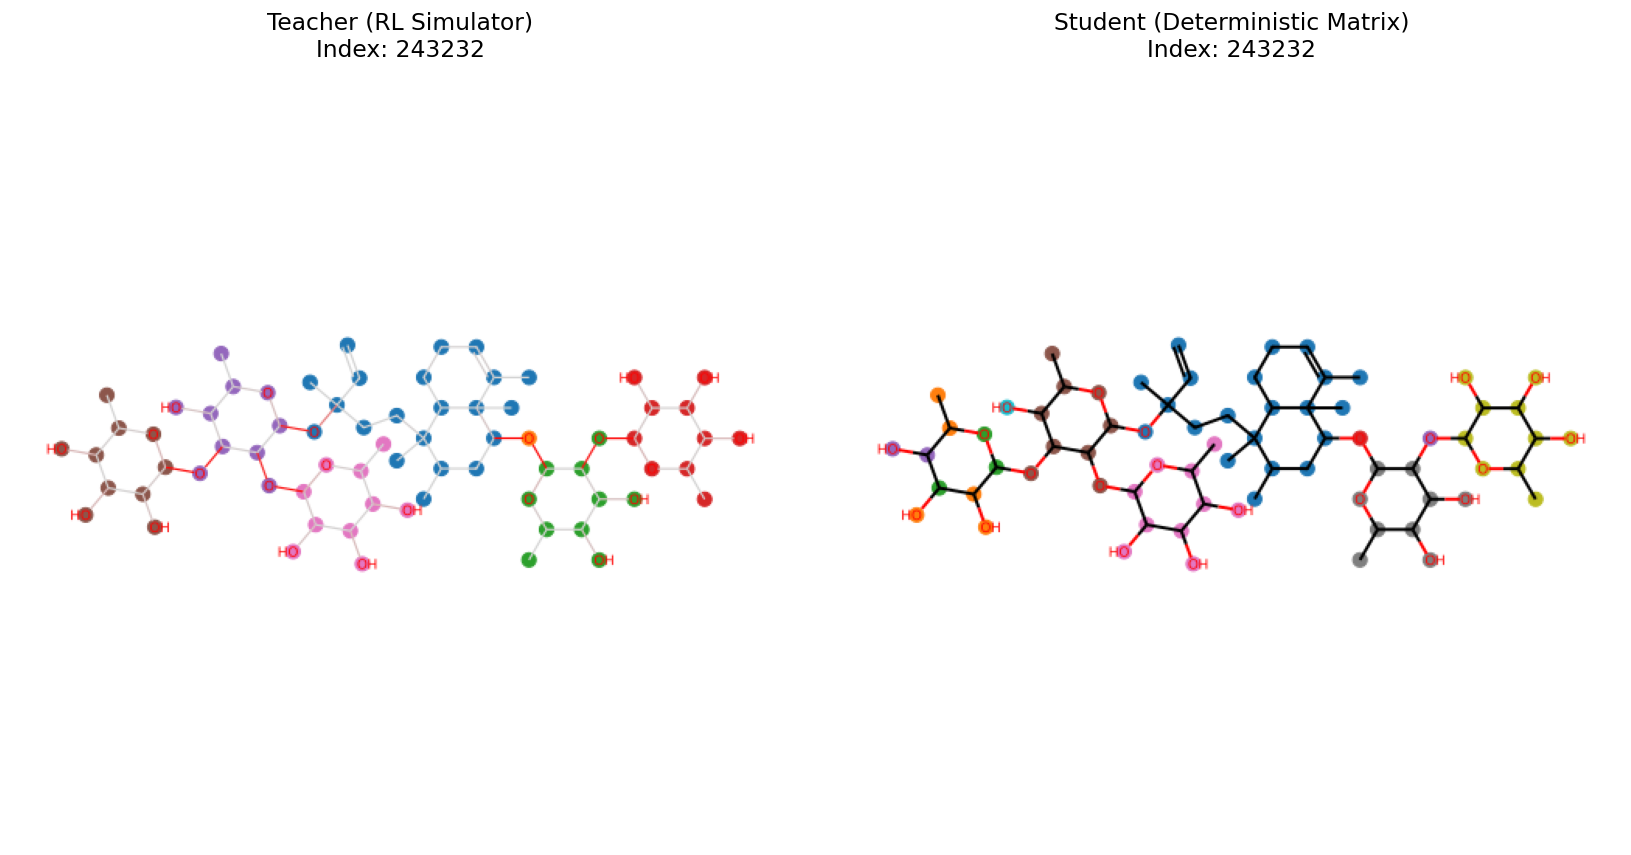

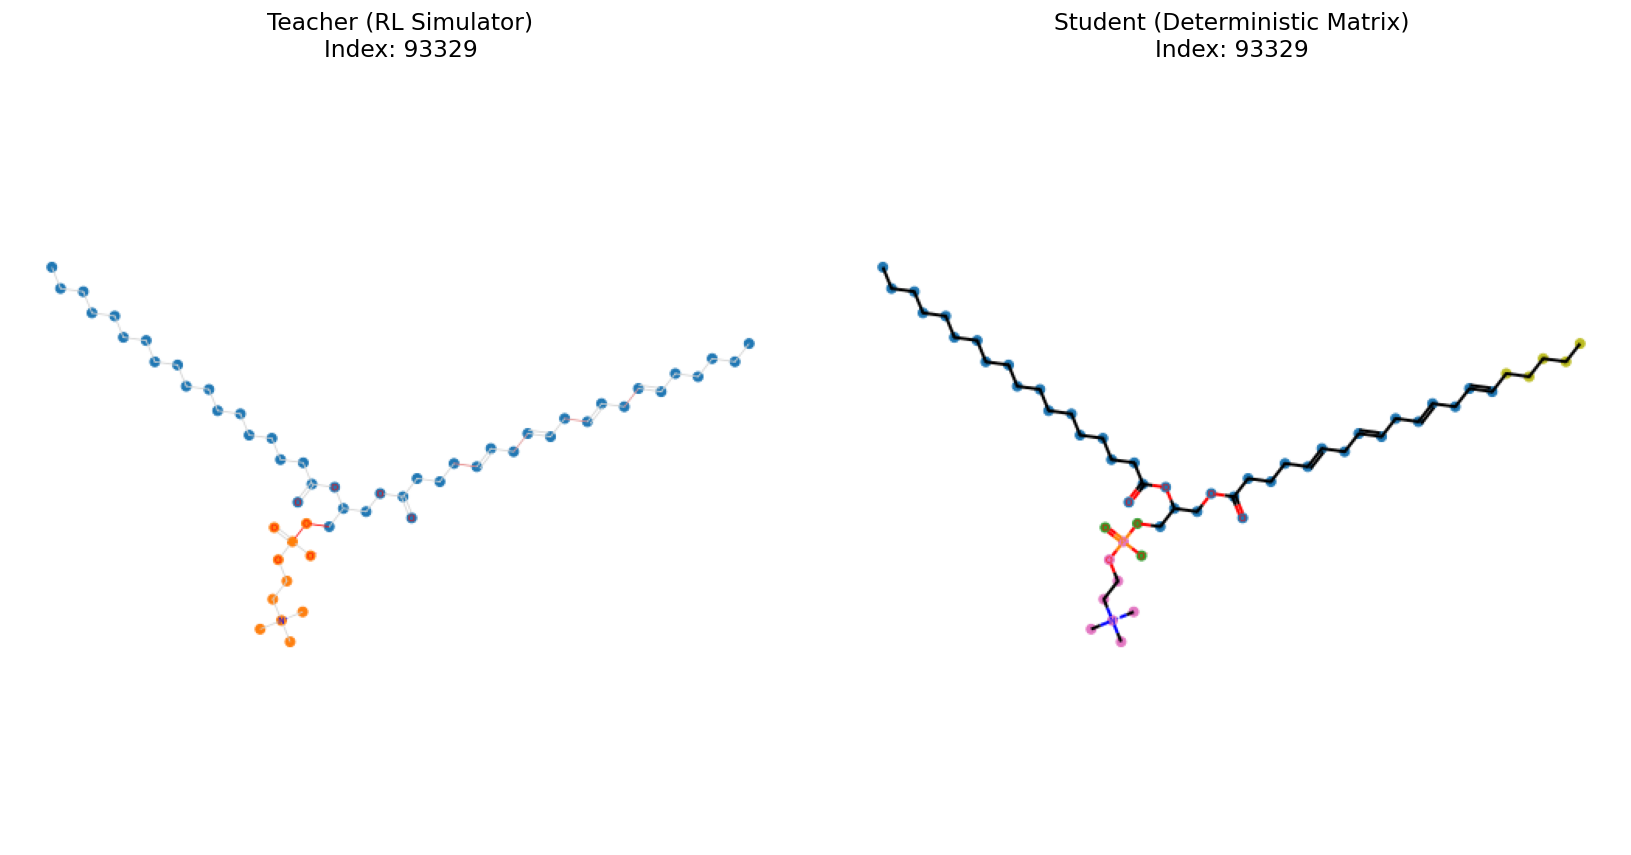

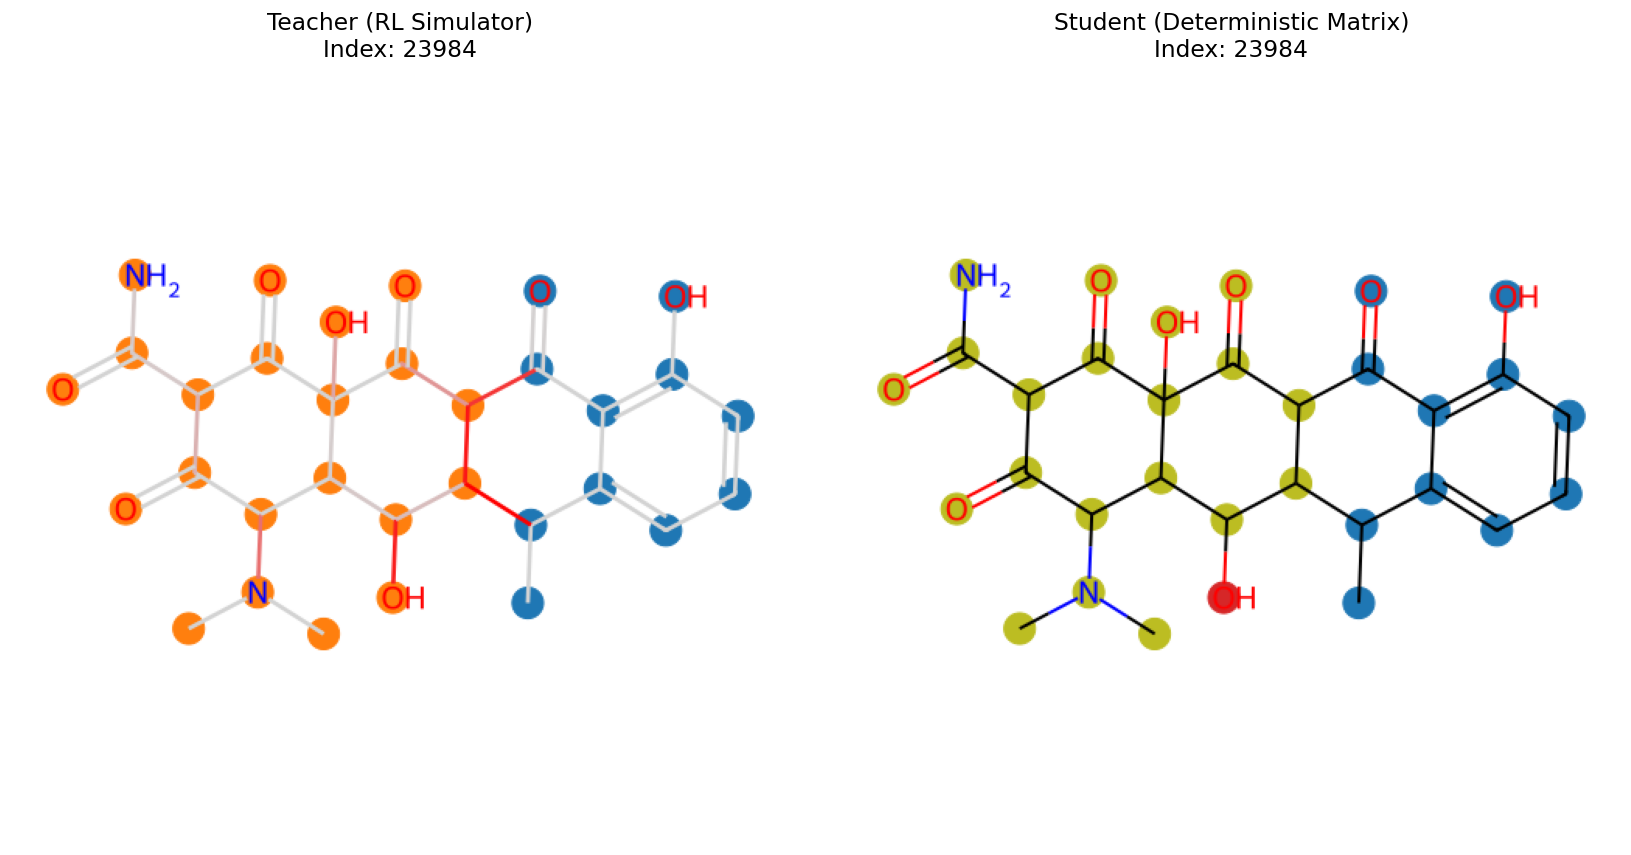

In [4]:
import torch
import yaml
import os
import sys
import random
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from io import BytesIO
from PIL import Image
from scipy.sparse.csgraph import connected_components
from torch_geometric.utils import to_scipy_sparse_matrix
from pathlib import Path
import matplotlib.cm as cm
import warnings

warnings.filterwarnings("ignore", message=".*nested tensors.*")

# =============================================================================
# 1. SETUP PATHS & IMPORTS
# =============================================================================
cwd = Path.cwd().parent
parent_directory = os.path.dirname(cwd.parent)

sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'fiar')) 
sys.path.insert(0, os.path.join(cwd, 'model', 'fiar'))
sys.path.insert(0, os.path.join(cwd, 'model', 'transport_model', 'bifurcate'))
sys.path.insert(0, os.path.join(parent_directory, 'tmach007', 'massformer', 'src'))
sys.path.insert(0, os.path.join(str(cwd), 'model', 'flare'))
sys.path.insert(0, os.path.join(parent_directory, 'tmach007', 'massformer', 'src', 'massformer'))

try:
    from phase2_dataloader import Phase2EdgeDataset, phase2_collate_fn
    from phase2_model_new import DESAFNet
    from deterministic_phase2 import DeterministicPhase2
except ImportError as e:
    print(f"[-] Error importing custom modules: {e}")
    raise e 

# =============================================================================
# 2. HELPER FUNCTIONS
# =============================================================================
def load_and_merge_configs(template_path, custom_path):
    with open(template_path, 'r', encoding='utf-8') as f: config = yaml.safe_load(f)
    if os.path.exists(custom_path):
        with open(custom_path, 'r', encoding='utf-8') as f: custom_config = yaml.safe_load(f)
        for section, subdict in custom_config.items():
            if isinstance(subdict, dict):
                if section not in config: config[section] = {}
                for k, v in subdict.items(): config[section][k] = v
            else: config[section] = subdict
    return config

def get_color_palette(num_colors):
    cmap = cm.get_cmap('tab10', num_colors)
    return {i: tuple(cmap(i)[:3]) for i in range(num_colors)}

def draw_molecule_to_image(mol, highlight_atoms, highlight_colors, highlight_bonds=None, highlight_bond_colors=None):
    """Renders RDKit molecule to a PIL Image."""
    drawer = rdMolDraw2D.MolDraw2DCairo(500, 500)
    opts = drawer.drawOptions()
    opts.continuousHighlight = False 
    opts.clearBackground = True
    
    drawer.DrawMolecule(
        mol, 
        highlightAtoms=highlight_atoms, 
        highlightAtomColors=highlight_colors,
        highlightBonds=highlight_bonds if highlight_bonds else [],
        highlightBondColors=highlight_bond_colors if highlight_bond_colors else {}
    )
    drawer.FinishDrawing()
    return Image.open(BytesIO(drawer.GetDrawingText()))

# =============================================================================
# 3. INITIALIZATION
# =============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Using device: {DEVICE}")

# Replace with your specific paths
DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/phase3_graphs.pt"
TEACHER_WEIGHTS = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/phase2_run3/desaf_phase2_best.pt"
STUDENT_WEIGHTS = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/fiar/deterministic_student_ep5.pt"
TEMPLATE_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"
CUSTOM_CONFIG_PATH = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"

print("[*] Loading Configs and Dataset...")
full_config = load_and_merge_configs(TEMPLATE_CONFIG_PATH, CUSTOM_CONFIG_PATH)
dataset = Phase2EdgeDataset(processed_graphs_path=DATA_PATH)

print("[*] Loading RL Teacher...")
teacher = DESAFNet(model_config=full_config['model']).to(DEVICE)
teacher.load_state_dict(torch.load(TEACHER_WEIGHTS, map_location=DEVICE), strict=False)
teacher.eval()

print("[*] Loading Distilled Student...")
student = DeterministicPhase2(full_config['model'], max_fragments=10).to(DEVICE)
student.load_state_dict(torch.load(STUDENT_WEIGHTS, map_location=DEVICE))
student.eval()

# =============================================================================
# 4. SIDE-BY-SIDE COMPARISON VISUALIZER
# =============================================================================
def compare_motifs(idx):
    mf_item = dataset[idx]
    if mf_item is None: return
        
    pyg_data = dataset.graphs[idx]
    smiles = pyg_data.smiles
    mol = Chem.MolFromSmiles(smiles)
    Chem.rdDepictor.Compute2DCoords(mol)
    num_atoms = mol.GetNumAtoms()

    batch = phase2_collate_fn([mf_item])
    batch = {k: v.to(DEVICE) if torch.is_tensor(v) else v for k, v in batch.items()}

    colors = get_color_palette(10)

    with torch.no_grad():
        # ---------------------------------------------------------
        # TEACHER (RL Physics)
        # ---------------------------------------------------------
        X_base = teacher.graph_encoder({'gf_v2_data': batch})
        X = X_base[0][:, 1:, :] if isinstance(X_base, tuple) else X_base[:, 1:, :]
        true_nodes = (batch['x'][0, :, 0] != 0).sum().item()
        X_flat = X[0, :true_nodes, :]
        edge_index = batch['edge_index']
        edge_attr = batch['edge_attr_physics']
        
        break_logits = teacher.edge_head(X_flat, edge_index, edge_attr).squeeze()
        break_probs = torch.sigmoid(break_logits)
        cut_actions = (break_probs > 0.5).long()
        
        surviving_mask = (cut_actions == 0)
        surviving_edge_index = edge_index[:, surviving_mask]
        
        adj_sparse = to_scipy_sparse_matrix(surviving_edge_index, num_nodes=true_nodes)
        _, teacher_labels = connected_components(adj_sparse, directed=False)
        
        # Format Teacher Output
        teacher_atom_colors = {i: colors[label % 10] for i, label in enumerate(teacher_labels)}
        
        # Optional: Color the cut bonds in the teacher plot
        cmap_bonds = LinearSegmentedColormap.from_list("prob", ["#d3d3d3", "#ff0000"])
        teacher_bond_colors = {}
        teacher_highlight_bonds = []
        for i in range(edge_index.shape[1]):
            u, v = edge_index[0, i].item(), edge_index[1, i].item()
            bond = mol.GetBondBetweenAtoms(u, v)
            if bond is not None:
                teacher_highlight_bonds.append(bond.GetIdx())
                teacher_bond_colors[bond.GetIdx()] = cmap_bonds(break_probs[i].item())[:3]

        # ---------------------------------------------------------
        # STUDENT (Deterministic Matrix)
        # ---------------------------------------------------------
        # [UPDATED] Unpack the new L_topo loss as well so it doesn't crash
        _, _, S, _ = student(batch)
        S_clean = S[0, :num_atoms, :]
        student_labels = torch.argmax(S_clean, dim=-1).cpu().numpy()
        
        # Format Student Output
        student_atom_colors = {i: colors[label % 10] for i, label in enumerate(student_labels)}

    # ---------------------------------------------------------
    # PLOTTING
    # ---------------------------------------------------------
    img_teacher = draw_molecule_to_image(
        mol, list(teacher_atom_colors.keys()), teacher_atom_colors,
        highlight_bonds=teacher_highlight_bonds, highlight_bond_colors=teacher_bond_colors
    )
    
    img_student = draw_molecule_to_image(
        mol, list(student_atom_colors.keys()), student_atom_colors
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), dpi=120)
    
    ax1.imshow(img_teacher)
    ax1.axis('off')
    ax1.set_title(f"Teacher (RL Simulator)\nIndex: {idx}", fontsize=14)
    
    ax2.imshow(img_student)
    ax2.axis('off')
    ax2.set_title(f"Student (Deterministic Matrix)\nIndex: {idx}", fontsize=14)
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# 5. EXECUTE RANDOM SAMPLES
# =============================================================================
print("\n[*] Fetching unique comparison samples...")
seen_smiles = set()
attempts = 0


while len(seen_smiles) < 3 and attempts < 100:
    idx = random.randint(0, len(dataset) - 1)
    attempts += 1
    
    if dataset[idx] is None: continue
    smiles = dataset.graphs[idx].smiles
    if smiles in seen_smiles: continue
        
    mol = Chem.MolFromSmiles(smiles)
    if mol.GetNumAtoms() > 10:  # Only plot interesting molecules
        seen_smiles.add(smiles)
        compare_motifs(idx)